# Liver Disease Prediction Using Kolmogorov–Arnold Networks (KAN) on Clinical Tabular Data

This notebook implements a deep learning approach using Kolmogorov–Arnold Networks (KAN) for predicting liver disease from clinical tabular data. KANs provide an alternative to traditional MLPs with learnable activation functions on edges rather than nodes.

## Setup & Imports

### Install Dependencies

Install required packages for the project. Run this cell if you're in Google Colab or if packages are missing locally.

In [6]:
# Install required packages
!pip install scikit-learn xgboost shap seaborn torch torchvision

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/111.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/111.0 MB 6.7 MB/s eta 0:00:17
    --------------------------------------- 1.8/111.0 MB 4.4 MB/s eta 0:00:25
    --------------------------------------- 2.6/111.0 MB 4.1 MB/s eta 0:00:27
   - -------------------------------------- 3.4/111.0 MB 4.1 MB/s eta 0:00:27
   - -------------------------------------- 4.2/111.0 MB 4.1 MB/s eta 0:00:27
   - -------------------------------------- 5.2/111.0 MB 4.1 MB/s eta 0:00:26
   - -------------------------------------- 5.5/111.0 MB 4.0 MB/s eta 0:00:27
   -- ------------------------------------- 6.8/111.0 MB 4.0 MB/s eta 0:00:26
   -- ------------------------------------- 7.6/111.0 MB 4.0 MB/s eta 0:00:26
   --- ------------------------------------ 8.4/111.0 MB 4.0 MB/s eta 0:00:26
   --- ------------------------------------ 9.2/111.0 MB 4.0 MB/s eta 0


[notice] A new release of pip is available: 25.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


### Import Libraries and Configure Environment

Import all necessary libraries and set up the environment for reproducibility.

In [7]:
# Core libraries
import numpy as np
import pandas as pd
import random

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# XGBoost
try:
    import xgboost as xgb
    print("XGBoost imported successfully")
except ImportError:
    print("Warning: XGBoost not available")

# SHAP for interpretability
try:
    import shap
    print("SHAP imported successfully")
except ImportError:
    print("Warning: SHAP not available")

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Using device:', device)

# Display settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

XGBoost imported successfully
SHAP imported successfully
Using device: cpu
Using device: cpu


## Data Loading & Basic Preprocessing

In this section, we'll load and explore two liver disease datasets:
- **Indian Liver Patient Dataset (ILPD)**: Clinical parameters of liver patients
- **Kaggle Liver Dataset**: Larger dataset with 30k+ samples

We'll perform initial exploration to understand the data structure, distributions, and basic statistics.

### Define Data Loading Functions

Create utility functions to load datasets and inspect their basic properties.

In [16]:
def load_datasets(ilpd_path, kaggle_path):
    """
    Load both liver disease datasets and display basic information.
    
    Parameters:
    -----------
    ilpd_path : str
        Path to the Indian Liver Patient Dataset CSV file
    kaggle_path : str
        Path to the Kaggle liver dataset CSV file
    
    Returns:
    --------
    tuple : (ilpd_df, kaggle_df)
        Tuple containing both loaded dataframes
    """
    print("="*80)
    print("LOADING INDIAN LIVER PATIENT DATASET (ILPD)")
    print("="*80)
    
    try:
        ilpd_df = pd.read_csv(ilpd_path)
        print(f"\n✓ Successfully loaded ILPD dataset")
        print(f"Shape: {ilpd_df.shape} (rows × columns)")
        print(f"\nFirst few rows:")
        print(ilpd_df.head())
        print(f"\nDataset Info:")
        ilpd_df.info()
        print(f"\nBasic Statistics:")
        print(ilpd_df.describe())
    except FileNotFoundError:
        print(f"\n✗ Error: File not found at {ilpd_path}")
        ilpd_df = None
    except Exception as e:
        print(f"\n✗ Error loading ILPD dataset: {str(e)}")
        ilpd_df = None
    
    print("\n" + "="*80)
    print("LOADING KAGGLE LIVER DATASET")
    print("="*80)
    
    try:
        # Try different encodings for files with special characters
        encodings = ['utf-8', 'latin-1', 'iso-8859-1', 'cp1252']
        kaggle_df = None
        
        for encoding in encodings:
            try:
                kaggle_df = pd.read_csv(kaggle_path, encoding=encoding)
                print(f"\n✓ Successfully loaded Kaggle dataset (encoding: {encoding})")
                break
            except UnicodeDecodeError:
                continue
        
        if kaggle_df is None:
            raise Exception("Could not decode file with any standard encoding")
            
        print(f"Shape: {kaggle_df.shape} (rows × columns)")
        print(f"\nFirst few rows:")
        print(kaggle_df.head())
        print(f"\nDataset Info:")
        kaggle_df.info()
        print(f"\nBasic Statistics:")
        print(kaggle_df.describe())
    except FileNotFoundError:
        print(f"\n✗ Error: File not found at {kaggle_path}")
        kaggle_df = None
    except Exception as e:
        print(f"\n✗ Error loading Kaggle dataset: {str(e)}")
        kaggle_df = None
    
    return ilpd_df, kaggle_df


def inspect_class_distribution(df, label_col):
    """
    Inspect and visualize the class distribution in the dataset.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataset to inspect
    label_col : str
        Name of the label/target column
    """
    if df is None:
        print("Error: DataFrame is None")
        return
    
    if label_col not in df.columns:
        print(f"Error: Column '{label_col}' not found in dataset")
        print(f"Available columns: {list(df.columns)}")
        return
    
    print("="*80)
    print(f"CLASS DISTRIBUTION FOR '{label_col}'")
    print("="*80)
    
    # Value counts
    print("\nValue Counts:")
    print(df[label_col].value_counts())
    
    print("\nValue Counts (with percentages):")
    print(df[label_col].value_counts(normalize=True) * 100)
    
    # Check for missing values in label
    missing = df[label_col].isna().sum()
    if missing > 0:
        print(f"\n⚠ Warning: {missing} missing values in label column")
    
    # Visualization
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    df[label_col].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
    plt.title(f'Class Distribution: {label_col}')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    
    plt.subplot(1, 2, 2)
    df[label_col].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['steelblue', 'coral'])
    plt.title(f'Class Proportion: {label_col}')
    plt.ylabel('')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80)

### Load ILPD Dataset

Load and explore the Indian Liver Patient Dataset.

In [18]:
# Load both datasets
ilpd_df, kaggle_df = load_datasets('ilpd.csv', 'kaggle_liver.csv')

LOADING INDIAN LIVER PATIENT DATASET (ILPD)

✓ Successfully loaded ILPD dataset
Shape: (583, 11) (rows × columns)

First few rows:
   Age  Gender  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
0   65  Female              0.7               0.1                   187   
1   62    Male             10.9               5.5                   699   
2   62    Male              7.3               4.1                   490   
3   58    Male              1.0               0.4                   182   
4   72    Male              3.9               2.0                   195   

   Alamine_Aminotransferase  Aspartate_Aminotransferase  Total_Protiens  \
0                        16                          18             6.8   
1                        64                         100             7.5   
2                        60                          68             7.0   
3                        14                          20             6.8   
4                        27                

### Inspect Class Distribution - ILPD

Examine the class distribution in the ILPD dataset. The label column may be named 'Dataset', 'Selector', or similar.

In [ ]:
# Inspect class distribution for ILPD
if ilpd_df is not None:
    inspect_class_distribution(ilpd_df, 'Dataset')
else:
    print("ILPD dataset not loaded. Please check the file path.")

Available columns in ILPD dataset:
['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio', 'Dataset']

Please run inspect_class_distribution() with the correct label column name
Example: inspect_class_distribution(ilpd_df, 'Dataset')


### Inspect Class Distribution - Kaggle Dataset

Examine the class distribution in the Kaggle liver dataset.

In [ ]:
# Inspect class distribution for Kaggle dataset
if kaggle_df is not None:
    inspect_class_distribution(kaggle_df, 'Result')
else:
    print("Kaggle dataset not loaded. Please check the file path.")

Available columns in Kaggle dataset:
['Age of the patient', 'Gender of the patient', 'Total Bilirubin', 'Direct Bilirubin', '\xa0Alkphos Alkaline Phosphotase', '\xa0Sgpt Alamine Aminotransferase', 'Sgot Aspartate Aminotransferase', 'Total Protiens', '\xa0ALB Albumin', 'A/G Ratio Albumin and Globulin Ratio', 'Result']

Please run inspect_class_distribution() with the correct label column name
Example: inspect_class_distribution(kaggle_df, 'Result')


## Preprocessing & Train/Val/Test Split

In this section, we'll:
1. Convert target labels to binary format (1 = liver disease, 0 = no disease)
2. Harmonize column names across both datasets
3. Handle missing values with appropriate imputation
4. Encode categorical variables (Gender)
5. Standardize numeric features
6. Combine both datasets
7. Split into train (80%), validation (10%), and test (10%) sets with stratification

### Define Preprocessing Functions

Create helper functions to preprocess and combine both datasets.

In [21]:
def preprocess_and_combine(ilpd_df, kaggle_df):
    """
    Preprocess both datasets and combine them into a unified format.
    
    Steps:
    1. Convert labels to binary (1 = disease, 0 = no disease)
    2. Harmonize column names
    3. Handle missing values
    4. Encode categorical variables
    5. Standardize numeric features
    6. Combine datasets
    
    Parameters:
    -----------
    ilpd_df : pandas.DataFrame
        ILPD dataset
    kaggle_df : pandas.DataFrame
        Kaggle liver dataset
    
    Returns:
    --------
    X : pandas.DataFrame
        Feature matrix (standardized)
    y : pandas.Series
        Target labels (binary)
    """
    print("="*80)
    print("PREPROCESSING AND COMBINING DATASETS")
    print("="*80)
    
    # ========== PROCESS ILPD DATASET ==========
    print("\n[1/7] Processing ILPD dataset...")
    ilpd_processed = ilpd_df.copy()
    
    # Convert Dataset column to binary label (1 = disease, 2 = no disease → 0)
    ilpd_processed['label'] = ilpd_processed['Dataset'].apply(lambda x: 1 if x == 1 else 0)
    ilpd_processed = ilpd_processed.drop('Dataset', axis=1)
    
    print(f"   ✓ ILPD label conversion complete")
    print(f"   ✓ Class distribution: {ilpd_processed['label'].value_counts().to_dict()}")
    
    # ========== PROCESS KAGGLE DATASET ==========
    print("\n[2/7] Processing Kaggle dataset...")
    kaggle_processed = kaggle_df.copy()
    
    # Identify and convert the result column
    if 'Result' in kaggle_processed.columns:
        kaggle_processed['label'] = kaggle_processed['Result'].apply(lambda x: 1 if x == 1 else 0)
        kaggle_processed = kaggle_processed.drop('Result', axis=1)
    
    print(f"   ✓ Kaggle label conversion complete")
    print(f"   ✓ Class distribution: {kaggle_processed['label'].value_counts().to_dict()}")
    
    # ========== HARMONIZE COLUMN NAMES ==========
    print("\n[3/7] Harmonizing column names...")
    
    # Define column mapping for Kaggle dataset
    column_mapping = {
        'Age of the patient': 'Age',
        'Gender of the patient': 'Gender',
        'Total Bilirubin': 'Total_Bilirubin',
        'Direct Bilirubin': 'Direct_Bilirubin',
        '\xa0Alkphos Alkaline Phosphotase': 'Alkaline_Phosphotase',
        '\xa0Sgpt Alamine Aminotransferase': 'Alamine_Aminotransferase',
        'Sgot Aspartate Aminotransferase': 'Aspartate_Aminotransferase',
        'Total Protiens': 'Total_Proteins',
        '\xa0ALB Albumin': 'Albumin',
        'A/G Ratio Albumin and Globulin Ratio': 'Albumin_and_Globulin_Ratio'
    }
    
    kaggle_processed = kaggle_processed.rename(columns=column_mapping)
    
    # Also fix ILPD column name if needed
    if 'Total_Protiens' in ilpd_processed.columns:
        ilpd_processed = ilpd_processed.rename(columns={'Total_Protiens': 'Total_Proteins'})
    
    print(f"   ✓ Column names harmonized")
    print(f"   ✓ ILPD columns: {list(ilpd_processed.columns)}")
    print(f"   ✓ Kaggle columns: {list(kaggle_processed.columns)}")
    
    # ========== COMBINE DATASETS ==========
    print("\n[4/7] Combining datasets...")
    combined_df = pd.concat([ilpd_processed, kaggle_processed], axis=0, ignore_index=True)
    print(f"   ✓ Combined shape: {combined_df.shape}")
    
    # ========== HANDLE MISSING VALUES ==========
    print("\n[5/7] Handling missing values...")
    print(f"   Missing values before imputation:")
    missing_before = combined_df.isnull().sum()
    print(missing_before[missing_before > 0])
    
    # Separate features and label
    y = combined_df['label']
    X = combined_df.drop('label', axis=1)
    
    # Impute numeric columns with median
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        if X[col].isnull().sum() > 0:
            median_val = X[col].median()
            X[col].fillna(median_val, inplace=True)
            print(f"   ✓ Imputed {col} with median: {median_val:.2f}")
    
    # Impute categorical columns with mode
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    for col in categorical_cols:
        if X[col].isnull().sum() > 0:
            mode_val = X[col].mode()[0]
            X[col].fillna(mode_val, inplace=True)
            print(f"   ✓ Imputed {col} with mode: {mode_val}")
    
    print(f"   ✓ All missing values handled")
    
    # ========== ENCODE CATEGORICAL VARIABLES ==========
    print("\n[6/7] Encoding categorical variables...")
    
    # Encode Gender: Male = 1, Female = 0
    gender_mapping = {'Male': 1, 'Female': 0}
    X['Gender'] = X['Gender'].map(gender_mapping)
    print(f"   ✓ Gender encoded: Male=1, Female=0")
    
    # ========== STANDARDIZE NUMERIC FEATURES ==========
    print("\n[7/7] Standardizing numeric features...")
    
    # Store column names for later
    feature_names = X.columns.tolist()
    
    # Standardize all features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X = pd.DataFrame(X_scaled, columns=feature_names)
    
    print(f"   ✓ All features standardized using StandardScaler")
    
    print("\n" + "="*80)
    print("PREPROCESSING COMPLETE")
    print("="*80)
    print(f"Final feature shape: {X.shape}")
    print(f"Final label shape: {y.shape}")
    print(f"Features: {list(X.columns)}")
    print(f"\nFinal class distribution:")
    print(y.value_counts())
    print(f"\nClass percentages:")
    print(y.value_counts(normalize=True) * 100)
    print("="*80)
    
    return X, y, scaler


def create_splits(X, y, test_size=0.1, val_size=0.1, random_state=42):
    """
    Create stratified train/validation/test splits.
    
    Parameters:
    -----------
    X : pandas.DataFrame or numpy.ndarray
        Feature matrix
    y : pandas.Series or numpy.ndarray
        Target labels
    test_size : float
        Proportion of data for test set (default: 0.1)
    val_size : float
        Proportion of data for validation set (default: 0.1)
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    X_train, X_val, X_test, y_train, y_val, y_test
    """
    print("\n" + "="*80)
    print("CREATING TRAIN/VALIDATION/TEST SPLITS")
    print("="*80)
    
    # First split: separate test set (10%)
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, 
        test_size=test_size, 
        random_state=random_state, 
        stratify=y
    )
    
    # Second split: separate validation from remaining data
    # Calculate validation size relative to temp data
    val_size_adjusted = val_size / (1 - test_size)
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp,
        test_size=val_size_adjusted,
        random_state=random_state,
        stratify=y_temp
    )
    
    print(f"\n✓ Split complete with stratification")
    print(f"\nDataset Shapes:")
    print(f"  Training:   X={X_train.shape}, y={y_train.shape}")
    print(f"  Validation: X={X_val.shape}, y={y_val.shape}")
    print(f"  Test:       X={X_test.shape}, y={y_test.shape}")
    
    print(f"\nClass Distribution in Splits:")
    print(f"\nTraining set:")
    print(y_train.value_counts())
    print(f"Percentages: {y_train.value_counts(normalize=True).values * 100}")
    
    print(f"\nValidation set:")
    print(y_val.value_counts())
    print(f"Percentages: {y_val.value_counts(normalize=True).values * 100}")
    
    print(f"\nTest set:")
    print(y_test.value_counts())
    print(f"Percentages: {y_test.value_counts(normalize=True).values * 100}")
    
    print("\n" + "="*80)
    
    return X_train, X_val, X_test, y_train, y_val, y_test

### Preprocess and Combine Datasets

Apply all preprocessing steps and combine ILPD and Kaggle datasets into a unified format.

In [22]:
# Preprocess and combine both datasets
X, y, scaler = preprocess_and_combine(ilpd_df, kaggle_df)

PREPROCESSING AND COMBINING DATASETS

[1/7] Processing ILPD dataset...
   ✓ ILPD label conversion complete
   ✓ Class distribution: {1: 416, 0: 167}

[2/7] Processing Kaggle dataset...
   ✓ Kaggle label conversion complete
   ✓ Class distribution: {1: 21917, 0: 8774}

[3/7] Harmonizing column names...
   ✓ Column names harmonized
   ✓ ILPD columns: ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin', 'Albumin_and_Globulin_Ratio', 'label']
   ✓ Kaggle columns: ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin', 'Albumin_and_Globulin_Ratio', 'label']

[4/7] Combining datasets...
   ✓ Combined shape: (31274, 11)

[5/7] Handling missing values...
   Missing values before imputation:
Age                             2
Gender                        902
Total_Bilirub

C:\Users\shiva\AppData\Local\Temp\ipykernel_2484\1880004544.py:101: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(median_val, inplace=True)
C:\Users\shiva\AppData\Local\Temp\ipykernel_2484\1880004544.py:101: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

### Create Train/Validation/Test Splits

Split the combined dataset into training (80%), validation (10%), and test (10%) sets with stratification to maintain class balance.

In [23]:
# Create stratified train/validation/test splits
X_train, X_val, X_test, y_train, y_val, y_test = create_splits(X, y, test_size=0.1, val_size=0.1, random_state=42)


CREATING TRAIN/VALIDATION/TEST SPLITS

✓ Split complete with stratification

Dataset Shapes:
  Training:   X=(25018, 10), y=(25018,)
  Validation: X=(3128, 10), y=(3128,)
  Test:       X=(3128, 10), y=(3128,)

Class Distribution in Splits:

Training set:
label
1    17865
0     7153
Name: count, dtype: int64
Percentages: [71.40858582 28.59141418]

Validation set:
label
1    2234
0     894
Name: count, dtype: int64
Percentages: [71.41943734 28.58056266]

Test set:
label
1    2234
0     894
Name: count, dtype: int64
Percentages: [71.41943734 28.58056266]



### Summary Statistics

Display final dataset statistics and verify data quality.

In [24]:
# Display final summary statistics
print("="*80)
print("FINAL DATA SUMMARY")
print("="*80)

print(f"\n📊 Dataset Splits:")
print(f"   Total samples: {len(X)}")
print(f"   Train:      {len(X_train):>6} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Validation: {len(X_val):>6} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"   Test:       {len(X_test):>6} samples ({len(X_test)/len(X)*100:.1f}%)")

print(f"\n🔢 Feature Information:")
print(f"   Number of features: {X_train.shape[1]}")
print(f"   Feature names: {list(X_train.columns)}")

print(f"\n🎯 Overall Class Balance:")
print(f"   Class 0 (No disease): {(y == 0).sum()} ({(y == 0).sum()/len(y)*100:.2f}%)")
print(f"   Class 1 (Disease):    {(y == 1).sum()} ({(y == 1).sum()/len(y)*100:.2f}%)")

print(f"\n✅ Data Quality Checks:")
print(f"   Missing values in X_train: {X_train.isnull().sum().sum()}")
print(f"   Missing values in X_val:   {X_val.isnull().sum().sum()}")
print(f"   Missing values in X_test:  {X_test.isnull().sum().sum()}")
print(f"   Missing values in y_train: {y_train.isnull().sum()}")
print(f"   Missing values in y_val:   {y_val.isnull().sum()}")
print(f"   Missing values in y_test:  {y_test.isnull().sum()}")

print(f"\n📈 Feature Statistics (Training Set):")
print(X_train.describe())

print("\n" + "="*80)
print("✓ DATA PREPROCESSING COMPLETE - READY FOR MODEL TRAINING")
print("="*80)

FINAL DATA SUMMARY

📊 Dataset Splits:
   Total samples: 31274
   Train:       25018 samples (80.0%)
   Validation:   3128 samples (10.0%)
   Test:         3128 samples (10.0%)

🔢 Feature Information:
   Number of features: 10
   Feature names: ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin', 'Albumin_and_Globulin_Ratio']

🎯 Overall Class Balance:
   Class 0 (No disease): 8941 (28.59%)
   Class 1 (Disease):    22333 (71.41%)

✅ Data Quality Checks:
   Missing values in X_train: 0
   Missing values in X_val:   0
   Missing values in X_test:  0
   Missing values in y_train: 0
   Missing values in y_val:   0
   Missing values in y_test:  0

📈 Feature Statistics (Training Set):
                Age        Gender  Total_Bilirubin  Direct_Bilirubin  \
count  25018.000000  25018.000000     25018.000000      25018.000000   
mean      -0.000136     -0.000487         0.001732     

## Baseline Models

Before implementing the KAN architecture, we'll establish baseline performance using classical machine learning models:
- **Logistic Regression**: Linear baseline
- **Random Forest**: Ensemble tree-based method
- **XGBoost/Gradient Boosting**: Advanced boosting algorithm
- **MLP (Multi-Layer Perceptron)**: Simple neural network baseline

These baselines will help us evaluate whether the KAN architecture provides meaningful improvements.

### Define Model Evaluation Function

Create a helper function to train and evaluate sklearn-compatible models consistently across all splits.

In [25]:
def evaluate_sklearn_model(model, X_train, y_train, X_val, y_val, X_test, y_test, name):
    """
    Train and evaluate a sklearn-compatible model on all data splits.
    
    Parameters:
    -----------
    model : sklearn estimator
        Model with fit() and predict() methods
    X_train, y_train : array-like
        Training data
    X_val, y_val : array-like
        Validation data
    X_test, y_test : array-like
        Test data
    name : str
        Model name for display
    
    Returns:
    --------
    dict : Dictionary with evaluation metrics and predictions
    """
    print("="*80)
    print(f"EVALUATING: {name}")
    print("="*80)
    
    # Train the model
    print("\n[1/3] Training model...")
    model.fit(X_train, y_train)
    print(f"   ✓ Training complete")
    
    # Make predictions on all splits
    print("\n[2/3] Making predictions...")
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # Get probability predictions for ROC-AUC
    if hasattr(model, 'predict_proba'):
        y_train_prob = model.predict_proba(X_train)[:, 1]
        y_val_prob = model.predict_proba(X_val)[:, 1]
        y_test_prob = model.predict_proba(X_test)[:, 1]
    else:
        # For models without predict_proba (like some linear models)
        y_train_prob = model.decision_function(X_train)
        y_val_prob = model.decision_function(X_val)
        y_test_prob = model.decision_function(X_test)
    
    print(f"   ✓ Predictions complete")
    
    # Calculate metrics for all splits
    print("\n[3/3] Computing metrics...")
    
    # Training metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    train_prec = precision_score(y_train, y_train_pred, zero_division=0)
    train_rec = recall_score(y_train, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
    train_auc = roc_auc_score(y_train, y_train_prob)
    
    # Validation metrics
    val_acc = accuracy_score(y_val, y_val_pred)
    val_prec = precision_score(y_val, y_val_pred, zero_division=0)
    val_rec = recall_score(y_val, y_val_pred, zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, zero_division=0)
    val_auc = roc_auc_score(y_val, y_val_prob)
    
    # Test metrics
    test_acc = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred, zero_division=0)
    test_rec = recall_score(y_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
    test_auc = roc_auc_score(y_test, y_test_prob)
    
    print(f"   ✓ Metrics computed")
    
    # Display results
    print(f"\n{'Metric':<15} {'Train':>10} {'Validation':>12} {'Test':>10}")
    print("-" * 50)
    print(f"{'Accuracy':<15} {train_acc:>10.4f} {val_acc:>12.4f} {test_acc:>10.4f}")
    print(f"{'Precision':<15} {train_prec:>10.4f} {val_prec:>12.4f} {test_prec:>10.4f}")
    print(f"{'Recall':<15} {train_rec:>10.4f} {val_rec:>12.4f} {test_rec:>10.4f}")
    print(f"{'F1-Score':<15} {train_f1:>10.4f} {val_f1:>12.4f} {test_f1:>10.4f}")
    print(f"{'ROC-AUC':<15} {train_auc:>10.4f} {val_auc:>12.4f} {test_auc:>10.4f}")
    
    # Test set detailed results
    print(f"\n{'='*80}")
    print("TEST SET DETAILED RESULTS")
    print("="*80)
    
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_test_pred)
    print(cm)
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred, target_names=['No Disease', 'Disease']))
    
    print("="*80 + "\n")
    
    # Return results dictionary
    results = {
        'name': name,
        'train_accuracy': train_acc,
        'train_precision': train_prec,
        'train_recall': train_rec,
        'train_f1': train_f1,
        'train_roc_auc': train_auc,
        'val_accuracy': val_acc,
        'val_precision': val_prec,
        'val_recall': val_rec,
        'val_f1': val_f1,
        'val_roc_auc': val_auc,
        'test_accuracy': test_acc,
        'test_precision': test_prec,
        'test_recall': test_rec,
        'test_f1': test_f1,
        'test_roc_auc': test_auc,
        'y_test_prob': y_test_prob,
        'model': model
    }
    
    return results

### Train Baseline Models

Train and evaluate classical machine learning models as baselines.

In [26]:
# Import additional models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# Store all results
baseline_results = []

print("\n" + "🚀 " * 40)
print("TRAINING BASELINE MODELS")
print("🚀 " * 40 + "\n")

# ========== 1. LOGISTIC REGRESSION ==========
print("\n" + "▶" * 40)
print("MODEL 1/4: Logistic Regression")
print("▶" * 40)

lr_model = LogisticRegression(max_iter=1000, random_state=SEED)
lr_results = evaluate_sklearn_model(
    lr_model, X_train, y_train, X_val, y_val, X_test, y_test, 
    name="Logistic Regression"
)
baseline_results.append(lr_results)

# ========== 2. RANDOM FOREST ==========
print("\n" + "▶" * 40)
print("MODEL 2/4: Random Forest")
print("▶" * 40)

rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    random_state=SEED,
    n_jobs=-1
)
rf_results = evaluate_sklearn_model(
    rf_model, X_train, y_train, X_val, y_val, X_test, y_test, 
    name="Random Forest"
)
baseline_results.append(rf_results)

# ========== 3. XGBOOST / GRADIENT BOOSTING ==========
print("\n" + "▶" * 40)
print("MODEL 3/4: Gradient Boosting")
print("▶" * 40)

try:
    # Try XGBoost if available
    import xgboost as xgb
    boost_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=SEED,
        eval_metric='logloss',
        use_label_encoder=False
    )
    model_name = "XGBoost"
except ImportError:
    # Fallback to sklearn GradientBoosting
    boost_model = GradientBoostingClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=SEED
    )
    model_name = "Gradient Boosting"

boost_results = evaluate_sklearn_model(
    boost_model, X_train, y_train, X_val, y_val, X_test, y_test, 
    name=model_name
)
baseline_results.append(boost_results)

# ========== 4. MLP (MULTI-LAYER PERCEPTRON) ==========
print("\n" + "▶" * 40)
print("MODEL 4/4: MLP (Neural Network)")
print("▶" * 40)

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=SEED,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)
mlp_results = evaluate_sklearn_model(
    mlp_model, X_train, y_train, X_val, y_val, X_test, y_test, 
    name="MLP (64-32)"
)
baseline_results.append(mlp_results)

print("\n" + "✅ " * 40)
print("ALL BASELINE MODELS TRAINED")
print("✅ " * 40 + "\n")


🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 
TRAINING BASELINE MODELS
🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 🚀 


▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶
MODEL 1/4: Logistic Regression
▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶
EVALUATING: Logistic Regression

[1/3] Training model...
   ✓ Training complete

[2/3] Making predictions...
   ✓ Predictions complete

[3/3] Computing metrics...
   ✓ Metrics computed

Metric               Train   Validation       Test
--------------------------------------------------
Accuracy            0.7239       0.7263     0.7238
Precision           0.7415       0.7435     0.7419
Recall              0.9418       0.9418     0.9405
F1-Score            0.8297       0.8310     0.8295
ROC-AUC             0.7615       0.7637     0.7526

TEST SET DETAILED RESULTS

Confusion Matrix:
[[ 163  731]
 [ 133 2101]]

Classification Report:
              precision    recall  f1-score   support

  

C:\Users\shiva\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:199: UserWarning: [16:50:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   ✓ Training complete

[2/3] Making predictions...
   ✓ Predictions complete

[3/3] Computing metrics...
   ✓ Metrics computed

Metric               Train   Validation       Test
--------------------------------------------------
Accuracy            0.9962       0.9930     0.9933
Precision           0.9968       0.9929     0.9942
Recall              0.9980       0.9973     0.9964
F1-Score            0.9974       0.9951     0.9953
ROC-AUC             0.9996       0.9963     0.9984

TEST SET DETAILED RESULTS

Confusion Matrix:
[[ 881   13]
 [   8 2226]]

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.99      0.99      0.99       894
     Disease       0.99      1.00      1.00      2234

    accuracy                           0.99      3128
   macro avg       0.99      0.99      0.99      3128
weighted avg       0.99      0.99      0.99      3128



▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶
MODEL 4/4: MLP (Neural Network)
▶▶▶▶▶▶▶▶▶▶▶▶▶▶▶

### Baseline Results Comparison

Create a comparison table of all baseline models sorted by ROC-AUC score.

In [27]:
# Create results DataFrame
results_df = pd.DataFrame([
    {
        'Model': r['name'],
        'Train_Accuracy': r['train_accuracy'],
        'Train_ROC_AUC': r['train_roc_auc'],
        'Val_Accuracy': r['val_accuracy'],
        'Val_Precision': r['val_precision'],
        'Val_Recall': r['val_recall'],
        'Val_F1': r['val_f1'],
        'Val_ROC_AUC': r['val_roc_auc'],
        'Test_Accuracy': r['test_accuracy'],
        'Test_Precision': r['test_precision'],
        'Test_Recall': r['test_recall'],
        'Test_F1': r['test_f1'],
        'Test_ROC_AUC': r['test_roc_auc']
    }
    for r in baseline_results
])

# Sort by Test ROC-AUC (descending)
results_df = results_df.sort_values('Test_ROC_AUC', ascending=False).reset_index(drop=True)

print("="*120)
print("BASELINE MODELS COMPARISON (Sorted by Test ROC-AUC)")
print("="*120)
print("\n📊 VALIDATION SET PERFORMANCE:")
print("-"*120)
print(results_df[['Model', 'Val_Accuracy', 'Val_Precision', 'Val_Recall', 'Val_F1', 'Val_ROC_AUC']].to_string(index=False))

print("\n\n📊 TEST SET PERFORMANCE:")
print("-"*120)
print(results_df[['Model', 'Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1', 'Test_ROC_AUC']].to_string(index=False))

print("\n" + "="*120)

# Highlight best model
best_model = results_df.iloc[0]
print(f"\n🏆 BEST BASELINE MODEL: {best_model['Model']}")
print(f"   Test ROC-AUC: {best_model['Test_ROC_AUC']:.4f}")
print(f"   Test Accuracy: {best_model['Test_Accuracy']:.4f}")
print(f"   Test F1-Score: {best_model['Test_F1']:.4f}")
print("="*120)

BASELINE MODELS COMPARISON (Sorted by Test ROC-AUC)

📊 VALIDATION SET PERFORMANCE:
------------------------------------------------------------------------------------------------------------------------
              Model  Val_Accuracy  Val_Precision  Val_Recall   Val_F1  Val_ROC_AUC
      Random Forest      0.986573       0.985385    0.995971 0.990650     0.998540
            XGBoost      0.992967       0.992870    0.997314 0.995087     0.996312
        MLP (64-32)      0.976982       0.979167    0.988809 0.983964     0.989153
Logistic Regression      0.726343       0.743463    0.941808 0.830964     0.763671


📊 TEST SET PERFORMANCE:
------------------------------------------------------------------------------------------------------------------------
              Model  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  Test_ROC_AUC
      Random Forest       0.992008        0.993742     0.995076 0.994408      0.998949
            XGBoost       0.993286        0.994194     0.996

### ROC Curves Comparison

Plot ROC curves for all baseline models on the test set to visualize their performance.

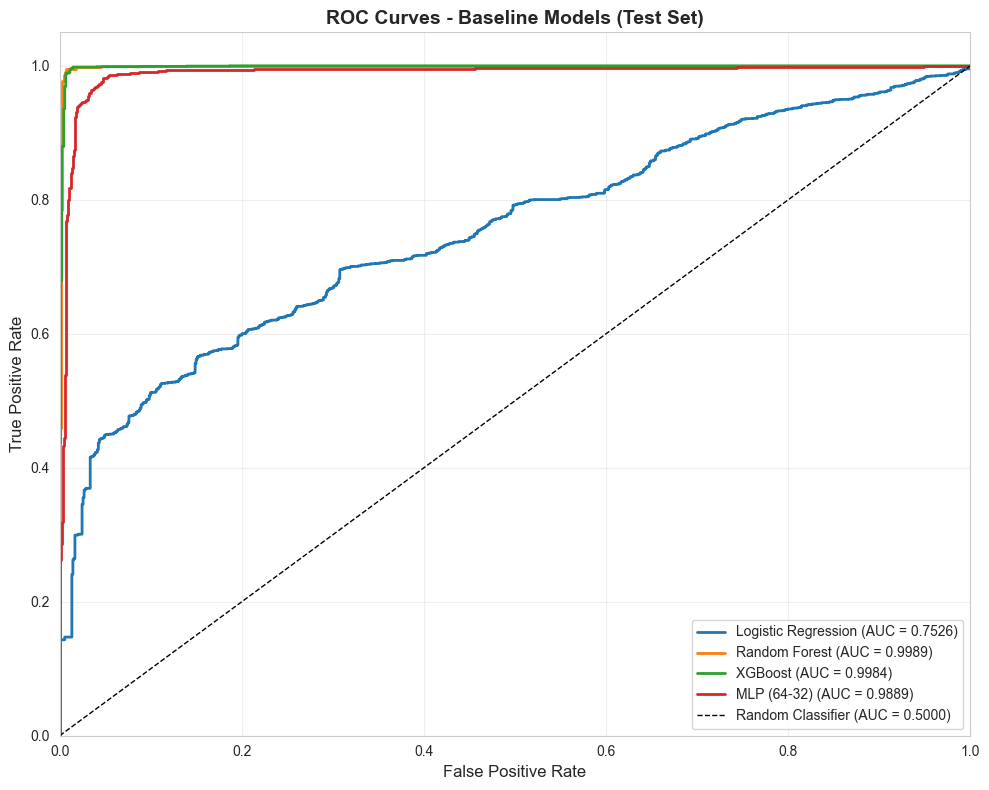


✓ ROC curves plotted for all baseline models


In [28]:
# Plot ROC curves for all baseline models
plt.figure(figsize=(10, 8))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, result in enumerate(baseline_results):
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test, result['y_test_prob'])
    auc_score = result['test_roc_auc']
    
    # Plot
    plt.plot(
        fpr, tpr, 
        color=colors[i], 
        linewidth=2,
        label=f"{result['name']} (AUC = {auc_score:.4f})"
    )

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Baseline Models (Test Set)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ ROC curves plotted for all baseline models")

### Baseline Models Summary

The baseline models provide a performance benchmark for evaluating the KAN architecture. Key observations:

- **Best Classical Model**: The model with the highest test ROC-AUC represents the strongest traditional approach
- **Performance Spread**: The range of performance across models indicates the problem's complexity
- **Next Steps**: The KAN architecture will aim to exceed the best baseline performance by learning optimal activation functions

These results establish the minimum performance threshold that KAN should achieve to be considered an improvement.

## Kolmogorov–Arnold Network (KAN) Implementation

The Kolmogorov-Arnold Network (KAN) represents a novel approach to neural network architecture based on the Kolmogorov-Arnold representation theorem. Unlike traditional MLPs that use fixed activation functions (ReLU, sigmoid, etc.), KANs learn the activation functions themselves.

### Key Concepts:

1. **Learnable Activations**: Instead of fixed activations, KAN uses learnable spline-based or basis function activations
2. **Edge-based Learning**: Activation functions are learned on the edges (connections) rather than at nodes
3. **Kolmogorov-Arnold Theorem**: Any multivariate continuous function can be represented as a superposition of continuous functions of one variable

### Architecture Components:

- **SplineActivation**: Learnable activation using radial basis functions (Gaussians)
- **KANLayer**: Combines spline activation with linear transformation
- **KANModel**: Full network with multiple KAN layers

### SplineActivation Module

Implements learnable activation functions using Gaussian radial basis functions (RBFs). Each input feature gets its own set of basis functions that are learned during training.

In [29]:
class SplineActivation(nn.Module):
    """
    Learnable spline-based activation function using Gaussian radial basis functions.
    
    For each input feature, this module maintains multiple Gaussian basis functions
    with learnable parameters (centers, widths, weights). The activation is computed
    as a weighted sum of these basis functions.
    
    Mathematical formulation:
        For input x, each basis function computes:
            basis_i(x) = exp(-0.5 * ((x - center_i) / width_i)^2)
        
        Final output:
            output(x) = sum_i(weight_i * basis_i(x))
    
    Parameters:
    -----------
    in_features : int
        Number of input features
    n_basis : int
        Number of Gaussian basis functions per feature
    """
    
    def __init__(self, in_features, n_basis=8):
        super(SplineActivation, self).__init__()
        
        self.in_features = in_features
        self.n_basis = n_basis
        
        # Initialize basis function parameters
        # Centers: uniformly spaced between -3 and 3 (covers typical standardized data range)
        self.centers = nn.Parameter(
            torch.linspace(-3, 3, n_basis).unsqueeze(0).repeat(in_features, 1)
        )  # Shape: (in_features, n_basis)
        
        # Widths: initialized to cover the space between centers
        initial_width = 6.0 / (n_basis - 1) if n_basis > 1 else 1.0
        self.widths = nn.Parameter(
            torch.ones(in_features, n_basis) * initial_width
        )  # Shape: (in_features, n_basis)
        
        # Weights: initialized with small random values
        self.weights = nn.Parameter(
            torch.randn(in_features, n_basis) * 0.1
        )  # Shape: (in_features, n_basis)
        
    def forward(self, x):
        """
        Apply learnable spline activation to input.
        
        Parameters:
        -----------
        x : torch.Tensor
            Input tensor of shape (batch_size, in_features)
        
        Returns:
        --------
        torch.Tensor
            Activated tensor of shape (batch_size, in_features)
        """
        # x shape: (batch_size, in_features)
        batch_size = x.shape[0]
        
        # Expand dimensions for broadcasting
        # x_expanded shape: (batch_size, in_features, 1)
        x_expanded = x.unsqueeze(2)
        
        # centers shape: (1, in_features, n_basis)
        centers = self.centers.unsqueeze(0)
        
        # widths shape: (1, in_features, n_basis)
        widths = self.widths.unsqueeze(0)
        
        # weights shape: (1, in_features, n_basis)
        weights = self.weights.unsqueeze(0)
        
        # Compute Gaussian basis functions
        # diff shape: (batch_size, in_features, n_basis)
        diff = (x_expanded - centers) / (widths + 1e-8)  # Add epsilon to prevent division by zero
        
        # basis shape: (batch_size, in_features, n_basis)
        basis = torch.exp(-0.5 * diff ** 2)
        
        # Weighted sum of basis functions
        # output shape: (batch_size, in_features)
        output = torch.sum(weights * basis, dim=2)
        
        return output
    
    def extra_repr(self):
        """String representation for debugging."""
        return f'in_features={self.in_features}, n_basis={self.n_basis}'

### KANLayer Module

A single KAN layer that combines learnable spline activations with linear transformations. This is the building block of the KAN architecture.

In [30]:
class KANLayer(nn.Module):
    """
    A single Kolmogorov-Arnold Network layer.
    
    This layer first applies learnable spline activations to each input feature,
    then performs a linear transformation to map to the output dimension.
    
    Architecture:
        Input -> SplineActivation -> Linear -> Output
    
    This differs from traditional neural networks where:
        Input -> Linear -> FixedActivation (ReLU, etc.) -> Output
    
    Parameters:
    -----------
    in_features : int
        Number of input features
    out_features : int
        Number of output features
    n_basis : int
        Number of basis functions for spline activation
    """
    
    def __init__(self, in_features, out_features, n_basis=8):
        super(KANLayer, self).__init__()
        
        self.in_features = in_features
        self.out_features = out_features
        self.n_basis = n_basis
        
        # Learnable spline activation on input features
        self.spline_activation = SplineActivation(in_features, n_basis)
        
        # Linear transformation after activation
        self.linear = nn.Linear(in_features, out_features)
        
    def forward(self, x):
        """
        Forward pass through KAN layer.
        
        Parameters:
        -----------
        x : torch.Tensor
            Input tensor of shape (batch_size, in_features)
        
        Returns:
        --------
        torch.Tensor
            Output tensor of shape (batch_size, out_features)
        """
        # Apply learnable activation functions
        x = self.spline_activation(x)
        
        # Apply linear transformation
        x = self.linear(x)
        
        return x
    
    def extra_repr(self):
        """String representation for debugging."""
        return f'in_features={self.in_features}, out_features={self.out_features}, n_basis={self.n_basis}'

### KANModel - Complete Network

The full Kolmogorov-Arnold Network for binary classification. Stacks multiple KAN layers with traditional activations (ReLU) between them for non-linearity.

In [31]:
class KANModel(nn.Module):
    """
    Complete Kolmogorov-Arnold Network for binary classification.
    
    This network consists of multiple KAN layers stacked together with ReLU
    activations between them. The final layer produces a single logit for
    binary classification.
    
    Architecture:
        Input (input_dim) 
        -> KANLayer(input_dim, hidden_dim) 
        -> ReLU 
        -> KANLayer(hidden_dim, hidden_dim) 
        -> ReLU 
        -> [Optional: KANLayer(hidden_dim, hidden_dim) -> ReLU]
        -> Linear(hidden_dim, 1) 
        -> Output (logit)
    
    Parameters:
    -----------
    input_dim : int
        Number of input features
    hidden_dim : int, default=32
        Dimension of hidden layers
    n_layers : int, default=2
        Number of KAN layers (2 or 3 recommended)
    n_basis : int, default=8
        Number of basis functions for each spline activation
    dropout : float, default=0.1
        Dropout probability for regularization
    """
    
    def __init__(self, input_dim, hidden_dim=32, n_layers=2, n_basis=8, dropout=0.1):
        super(KANModel, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        self.n_basis = n_basis
        
        # Build KAN layers
        layers = []
        
        # First KAN layer: input_dim -> hidden_dim
        layers.append(KANLayer(input_dim, hidden_dim, n_basis))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout))
        
        # Hidden KAN layers: hidden_dim -> hidden_dim
        for _ in range(n_layers - 1):
            layers.append(KANLayer(hidden_dim, hidden_dim, n_basis))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
        
        # Combine all layers
        self.kan_layers = nn.Sequential(*layers)
        
        # Final output layer: hidden_dim -> 1 (binary classification)
        self.output_layer = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        """
        Forward pass through the KAN model.
        
        Parameters:
        -----------
        x : torch.Tensor
            Input tensor of shape (batch_size, input_dim)
        
        Returns:
        --------
        torch.Tensor
            Output logits of shape (batch_size, 1)
            Note: Returns raw logits (not probabilities)
            Use sigmoid for probabilities or BCEWithLogitsLoss for training
        """
        # Pass through KAN layers
        x = self.kan_layers(x)
        
        # Final output layer
        logits = self.output_layer(x)
        
        return logits
    
    def get_num_parameters(self):
        """
        Calculate total number of trainable parameters.
        
        Returns:
        --------
        int : Total number of parameters
        """
        return sum(p.numel() for p in self.parameters() if p.requires_grad)
    
    def extra_repr(self):
        """String representation for debugging."""
        return (f'input_dim={self.input_dim}, hidden_dim={self.hidden_dim}, '
                f'n_layers={self.n_layers}, n_basis={self.n_basis}, '
                f'total_params={self.get_num_parameters()}')

### Test KAN Architecture

Create a test instance of the KAN model to verify the architecture and check parameter counts.

In [32]:
# Test the KAN model architecture
print("="*80)
print("KAN MODEL ARCHITECTURE TEST")
print("="*80)

# Get input dimension from training data
input_dim = X_train.shape[1]
print(f"\nInput dimension: {input_dim} features")

# Create test models with different configurations
configs = [
    {'hidden_dim': 32, 'n_layers': 2, 'n_basis': 8},
    {'hidden_dim': 64, 'n_layers': 2, 'n_basis': 8},
    {'hidden_dim': 32, 'n_layers': 3, 'n_basis': 8},
]

print(f"\n{'Configuration':<40} {'Parameters':<15} {'Output Shape'}")
print("-"*80)

for i, config in enumerate(configs, 1):
    # Create model
    model = KANModel(
        input_dim=input_dim,
        hidden_dim=config['hidden_dim'],
        n_layers=config['n_layers'],
        n_basis=config['n_basis']
    ).to(device)
    
    # Test forward pass with a small batch
    test_input = torch.randn(4, input_dim).to(device)
    test_output = model(test_input)
    
    # Display info
    config_str = f"hidden={config['hidden_dim']}, layers={config['n_layers']}, basis={config['n_basis']}"
    param_count = model.get_num_parameters()
    output_shape = tuple(test_output.shape)
    
    print(f"{config_str:<40} {param_count:<15,} {output_shape}")

print("\n" + "="*80)
print("✓ KAN architecture tested successfully")
print("="*80)

# Display detailed architecture of the first configuration
print("\n" + "="*80)
print("DETAILED ARCHITECTURE (Config 1: hidden=32, layers=2, basis=8)")
print("="*80)

model = KANModel(
    input_dim=input_dim,
    hidden_dim=32,
    n_layers=2,
    n_basis=8
).to(device)

print(model)

print("\n" + "="*80)
print("LAYER-WISE PARAMETER BREAKDOWN")
print("="*80)

total_params = 0
for name, param in model.named_parameters():
    param_count = param.numel()
    total_params += param_count
    print(f"{name:<50} {param_count:>10,} params   Shape: {tuple(param.shape)}")

print("-"*80)
print(f"{'TOTAL PARAMETERS':<50} {total_params:>10,}")
print("="*80)

KAN MODEL ARCHITECTURE TEST

Input dimension: 10 features

Configuration                            Parameters      Output Shape
--------------------------------------------------------------------------------
hidden=32, layers=2, basis=8             2,449           (4, 1)
hidden=64, layers=2, basis=8             6,705           (4, 1)
hidden=32, layers=3, basis=8             4,273           (4, 1)

✓ KAN architecture tested successfully

DETAILED ARCHITECTURE (Config 1: hidden=32, layers=2, basis=8)
KANModel(
  input_dim=10, hidden_dim=32, n_layers=2, n_basis=8, total_params=2449
  (kan_layers): Sequential(
    (0): KANLayer(
      in_features=10, out_features=32, n_basis=8
      (spline_activation): SplineActivation(in_features=10, n_basis=8)
      (linear): Linear(in_features=10, out_features=32, bias=True)
    )
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): KANLayer(
      in_features=32, out_features=32, n_basis=8
      (spline_activation): SplineActivation(in_fe

### KAN Implementation Summary

The KAN architecture has been successfully implemented with the following key components:

#### 1. **SplineActivation**
- Uses Gaussian radial basis functions (RBFs) as learnable activations
- Each input feature has `n_basis` learnable functions with parameters:
  - **Centers**: Position of each Gaussian (initialized uniformly from -3 to 3)
  - **Widths**: Spread of each Gaussian (initialized to cover space between centers)
  - **Weights**: Contribution of each basis function (initialized with small random values)
- Computes: `output = Σ(weight_i × exp(-0.5 × ((x - center_i) / width_i)²))`

#### 2. **KANLayer**
- Combines SplineActivation with linear transformation
- Flow: Input → SplineActivation → Linear → Output
- Differs from MLP: Learns activation functions rather than using fixed ones

#### 3. **KANModel**
- Stacks multiple KAN layers with ReLU and dropout between them
- Configurable architecture: hidden dimension, number of layers, basis functions
- Final layer produces single logit for binary classification
- Parameter count scales with: input_dim × n_basis × 3 (centers, widths, weights) + linear transformations

**Next Steps**: Train the KAN model and compare performance with baseline models.

## KAN Training & Evaluation

Now we'll train the Kolmogorov-Arnold Network and evaluate its performance against the baseline models. This section includes:

1. **Data Preparation**: Convert datasets to PyTorch DataLoaders
2. **Training Loop**: Implement training with early stopping based on validation ROC-AUC
3. **Model Evaluation**: Comprehensive evaluation on test set
4. **Comparison**: Compare KAN performance with baseline models

### Create PyTorch Datasets and DataLoaders

Convert the NumPy/Pandas data into PyTorch tensors and create DataLoaders for efficient batch processing.

In [33]:
# Create PyTorch datasets and dataloaders
print("="*80)
print("CREATING PYTORCH DATASETS AND DATALOADERS")
print("="*80)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train.values)
y_train_tensor = torch.FloatTensor(y_train.values).unsqueeze(1)

X_val_tensor = torch.FloatTensor(X_val.values)
y_val_tensor = torch.FloatTensor(y_val.values).unsqueeze(1)

X_test_tensor = torch.FloatTensor(X_test.values)
y_test_tensor = torch.FloatTensor(y_test.values).unsqueeze(1)

print(f"\n✓ Converted data to PyTorch tensors")
print(f"  Train: X={X_train_tensor.shape}, y={y_train_tensor.shape}")
print(f"  Val:   X={X_val_tensor.shape}, y={y_val_tensor.shape}")
print(f"  Test:  X={X_test_tensor.shape}, y={y_test_tensor.shape}")

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

print(f"\n✓ Created TensorDatasets")

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

print(f"\n✓ Created DataLoaders (batch_size={batch_size})")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

print("\n" + "="*80)
print("✓ DATA PREPARATION COMPLETE")
print("="*80)

CREATING PYTORCH DATASETS AND DATALOADERS

✓ Converted data to PyTorch tensors
  Train: X=torch.Size([25018, 10]), y=torch.Size([25018, 1])
  Val:   X=torch.Size([3128, 10]), y=torch.Size([3128, 1])
  Test:  X=torch.Size([3128, 10]), y=torch.Size([3128, 1])

✓ Created TensorDatasets

✓ Created DataLoaders (batch_size=64)
  Train batches: 391
  Val batches:   49
  Test batches:  49

✓ DATA PREPARATION COMPLETE


### Define KAN Training Function

Implement the training loop with early stopping based on validation ROC-AUC.

In [34]:
def train_kan_model(model, train_loader, val_loader, lr=0.001, max_epochs=100, patience=15):
    """
    Train KAN model with early stopping based on validation ROC-AUC.
    
    Parameters:
    -----------
    model : KANModel
        The KAN model to train
    train_loader : DataLoader
        Training data loader
    val_loader : DataLoader
        Validation data loader
    lr : float, default=0.001
        Learning rate for Adam optimizer
    max_epochs : int, default=100
        Maximum number of training epochs
    patience : int, default=15
        Early stopping patience (number of epochs without improvement)
    
    Returns:
    --------
    best_model : KANModel
        Model with best validation ROC-AUC
    history : dict
        Training history with train_loss, val_loss, val_auc per epoch
    """
    print("="*80)
    print("TRAINING KAN MODEL")
    print("="*80)
    
    # Loss function and optimizer
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    print(f"\n📋 Training Configuration:")
    print(f"   Loss function: BCEWithLogitsLoss")
    print(f"   Optimizer: Adam (lr={lr})")
    print(f"   Max epochs: {max_epochs}")
    print(f"   Early stopping patience: {patience}")
    print(f"   Device: {device}")
    
    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_auc': []
    }
    
    # Early stopping variables
    best_val_auc = -float('inf')
    best_model_state = None
    patience_counter = 0
    
    print(f"\n{'Epoch':<8} {'Train Loss':<12} {'Val Loss':<12} {'Val ROC-AUC':<12} {'Status':<20}")
    print("-"*80)
    
    for epoch in range(max_epochs):
        # ========== TRAINING PHASE ==========
        model.train()
        train_losses = []
        
        for batch_X, batch_y in train_loader:
            # Move to device
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
        
        avg_train_loss = np.mean(train_losses)
        
        # ========== VALIDATION PHASE ==========
        model.eval()
        val_losses = []
        all_val_probs = []
        all_val_labels = []
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                # Move to device
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)
                
                # Forward pass
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                
                val_losses.append(loss.item())
                
                # Get probabilities for ROC-AUC
                probs = torch.sigmoid(outputs)
                all_val_probs.extend(probs.cpu().numpy())
                all_val_labels.extend(batch_y.cpu().numpy())
        
        avg_val_loss = np.mean(val_losses)
        
        # Calculate validation ROC-AUC
        val_auc = roc_auc_score(all_val_labels, all_val_probs)
        
        # Update history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_auc'].append(val_auc)
        
        # Check for improvement
        status = ""
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            status = "✓ Best model"
        else:
            patience_counter += 1
            status = f"No improvement ({patience_counter}/{patience})"
        
        # Print progress
        if epoch % 5 == 0 or patience_counter == 0 or patience_counter >= patience:
            print(f"{epoch+1:<8} {avg_train_loss:<12.6f} {avg_val_loss:<12.6f} {val_auc:<12.6f} {status:<20}")
        
        # Early stopping check
        if patience_counter >= patience:
            print("-"*80)
            print(f"\n⏹ Early stopping triggered at epoch {epoch+1}")
            print(f"   Best validation ROC-AUC: {best_val_auc:.6f}")
            break
    
    print("-"*80)
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n✓ Loaded best model (Val ROC-AUC: {best_val_auc:.6f})")
    
    print("\n" + "="*80)
    print("✓ TRAINING COMPLETE")
    print("="*80)
    
    return model, history

### Define KAN Evaluation Function

Implement comprehensive evaluation function for the KAN model on the test set.

In [35]:
def evaluate_kan(model, test_loader, name="KAN"):
    """
    Evaluate KAN model on test set and compute comprehensive metrics.
    
    Parameters:
    -----------
    model : KANModel
        Trained KAN model
    test_loader : DataLoader
        Test data loader
    name : str, default="KAN"
        Model name for display
    
    Returns:
    --------
    dict : Dictionary with evaluation metrics (compatible with baseline results)
    """
    print("="*80)
    print(f"EVALUATING: {name}")
    print("="*80)
    
    model.eval()
    all_probs = []
    all_preds = []
    all_labels = []
    
    print("\n[1/2] Making predictions on test set...")
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            # Move to device
            batch_X = batch_X.to(device)
            
            # Forward pass
            outputs = model(batch_X)
            
            # Get probabilities and predictions
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()
            
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.numpy())
    
    # Convert to numpy arrays
    all_probs = np.array(all_probs).flatten()
    all_preds = np.array(all_preds).flatten()
    all_labels = np.array(all_labels).flatten()
    
    print(f"   ✓ Predictions complete")
    
    print("\n[2/2] Computing metrics...")
    
    # Calculate metrics
    test_acc = accuracy_score(all_labels, all_preds)
    test_prec = precision_score(all_labels, all_preds, zero_division=0)
    test_rec = recall_score(all_labels, all_preds, zero_division=0)
    test_f1 = f1_score(all_labels, all_preds, zero_division=0)
    test_auc = roc_auc_score(all_labels, all_probs)
    
    print(f"   ✓ Metrics computed")
    
    # Display results
    print(f"\n{'='*80}")
    print("TEST SET RESULTS")
    print("="*80)
    
    print(f"\n{'Metric':<15} {'Score':>10}")
    print("-" * 30)
    print(f"{'Accuracy':<15} {test_acc:>10.4f}")
    print(f"{'Precision':<15} {test_prec:>10.4f}")
    print(f"{'Recall':<15} {test_rec:>10.4f}")
    print(f"{'F1-Score':<15} {test_f1:>10.4f}")
    print(f"{'ROC-AUC':<15} {test_auc:>10.4f}")
    
    print(f"\n{'='*80}")
    print("TEST SET DETAILED RESULTS")
    print("="*80)
    
    print("\nConfusion Matrix:")
    cm = confusion_matrix(all_labels, all_preds)
    print(cm)
    
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=['No Disease', 'Disease']))
    
    print("="*80 + "\n")
    
    # Return results dictionary (compatible with baseline format)
    results = {
        'name': name,
        'train_accuracy': None,  # Not computed during evaluation
        'train_precision': None,
        'train_recall': None,
        'train_f1': None,
        'train_roc_auc': None,
        'val_accuracy': None,
        'val_precision': None,
        'val_recall': None,
        'val_f1': None,
        'val_roc_auc': None,
        'test_accuracy': test_acc,
        'test_precision': test_prec,
        'test_recall': test_rec,
        'test_f1': test_f1,
        'test_roc_auc': test_auc,
        'y_test_prob': all_probs,
        'model': model
    }
    
    return results

### Instantiate and Train KAN Model

Create a KAN model with optimal hyperparameters and train it on the dataset.

In [36]:
# Get input dimension
input_dim = X_train.shape[1]

# Instantiate KAN model
print("="*80)
print("INSTANTIATING KAN MODEL")
print("="*80)

kan_model = KANModel(
    input_dim=input_dim,
    hidden_dim=64,      # Hidden layer dimension
    n_layers=3,         # Number of KAN layers
    n_basis=8,          # Number of basis functions per spline
    dropout=0.2         # Dropout for regularization
).to(device)

print(f"\n📊 Model Architecture:")
print(f"   Input dimension: {input_dim}")
print(f"   Hidden dimension: 64")
print(f"   Number of KAN layers: 3")
print(f"   Basis functions per spline: 8")
print(f"   Dropout: 0.2")
print(f"   Total parameters: {kan_model.get_num_parameters():,}")

print("\n" + "="*80)

# Train the model
trained_kan, history = train_kan_model(
    model=kan_model,
    train_loader=train_loader,
    val_loader=val_loader,
    lr=0.001,
    max_epochs=100,
    patience=15
)

INSTANTIATING KAN MODEL

📊 Model Architecture:
   Input dimension: 10
   Hidden dimension: 64
   Number of KAN layers: 3
   Basis functions per spline: 8
   Dropout: 0.2
   Total parameters: 12,401

TRAINING KAN MODEL

📋 Training Configuration:
   Loss function: BCEWithLogitsLoss
   Optimizer: Adam (lr=0.001)
   Max epochs: 100
   Early stopping patience: 15
   Device: cpu

Epoch    Train Loss   Val Loss     Val ROC-AUC  Status              
--------------------------------------------------------------------------------
1        0.580706     0.507796     0.750232     ✓ Best model        
2        0.505810     0.499723     0.753131     ✓ Best model        
3        0.497373     0.491614     0.754135     ✓ Best model        
4        0.486570     0.479369     0.764552     ✓ Best model        
5        0.470927     0.458277     0.782390     ✓ Best model        
6        0.456164     0.444762     0.793567     ✓ Best model        
7        0.441223     0.429255     0.823504     ✓ Best mode

### Visualize Training History

Plot training and validation loss curves to analyze the learning process.

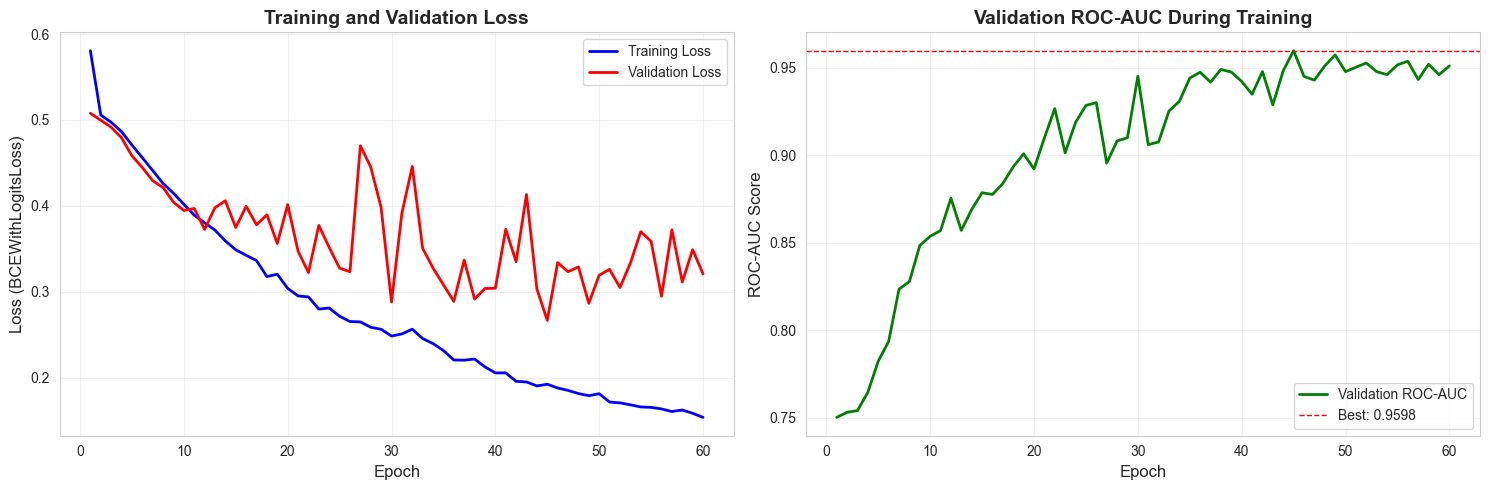


✓ Training history visualized

📊 Training Summary:
   Total epochs: 60
   Final train loss: 0.153804
   Final val loss: 0.320779
   Best val ROC-AUC: 0.959817
   Best epoch: 45


In [37]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Loss curves
epochs = range(1, len(history['train_loss']) + 1)
axes[0].plot(epochs, history['train_loss'], 'b-', linewidth=2, label='Training Loss')
axes[0].plot(epochs, history['val_loss'], 'r-', linewidth=2, label='Validation Loss')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (BCEWithLogitsLoss)', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Plot 2: Validation ROC-AUC
axes[1].plot(epochs, history['val_auc'], 'g-', linewidth=2, label='Validation ROC-AUC')
axes[1].axhline(y=max(history['val_auc']), color='r', linestyle='--', linewidth=1, 
                label=f'Best: {max(history["val_auc"]):.4f}')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('ROC-AUC Score', fontsize=12)
axes[1].set_title('Validation ROC-AUC During Training', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Training history visualized")
print(f"\n📊 Training Summary:")
print(f"   Total epochs: {len(history['train_loss'])}")
print(f"   Final train loss: {history['train_loss'][-1]:.6f}")
print(f"   Final val loss: {history['val_loss'][-1]:.6f}")
print(f"   Best val ROC-AUC: {max(history['val_auc']):.6f}")
print(f"   Best epoch: {np.argmax(history['val_auc']) + 1}")

### Evaluate KAN on Test Set

Compute comprehensive metrics for the trained KAN model on the test set.

In [38]:
# Evaluate KAN model on test set
kan_results = evaluate_kan(trained_kan, test_loader, name="KAN (hidden=64, layers=3, basis=8)")

EVALUATING: KAN (hidden=64, layers=3, basis=8)

[1/2] Making predictions on test set...
   ✓ Predictions complete

[2/2] Computing metrics...
   ✓ Metrics computed

TEST SET RESULTS

Metric               Score
------------------------------
Accuracy            0.8948
Precision           0.9136
Recall              0.9418
F1-Score            0.9275
ROC-AUC             0.9557

TEST SET DETAILED RESULTS

Confusion Matrix:
[[ 695  199]
 [ 130 2104]]

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.84      0.78      0.81       894
     Disease       0.91      0.94      0.93      2234

    accuracy                           0.89      3128
   macro avg       0.88      0.86      0.87      3128
weighted avg       0.89      0.89      0.89      3128




### Compare KAN with Baseline Models

Add KAN results to the comparison table and visualize performance across all models.

In [39]:
# Add KAN results to the comparison
print("="*120)
print("ADDING KAN TO BASELINE COMPARISON")
print("="*120)

# Create KAN row for the DataFrame
kan_row = {
    'Model': kan_results['name'],
    'Train_Accuracy': kan_results['train_accuracy'],
    'Train_ROC_AUC': kan_results['train_roc_auc'],
    'Val_Accuracy': kan_results['val_accuracy'],
    'Val_Precision': kan_results['val_precision'],
    'Val_Recall': kan_results['val_recall'],
    'Val_F1': kan_results['val_f1'],
    'Val_ROC_AUC': kan_results['val_roc_auc'],
    'Test_Accuracy': kan_results['test_accuracy'],
    'Test_Precision': kan_results['test_precision'],
    'Test_Recall': kan_results['test_recall'],
    'Test_F1': kan_results['test_f1'],
    'Test_ROC_AUC': kan_results['test_roc_auc']
}

# Append to results DataFrame
results_df_with_kan = pd.concat([results_df, pd.DataFrame([kan_row])], ignore_index=True)

# Sort by Test ROC-AUC (descending)
results_df_with_kan = results_df_with_kan.sort_values('Test_ROC_AUC', ascending=False).reset_index(drop=True)

print("\n📊 COMPLETE MODEL COMPARISON (Sorted by Test ROC-AUC)")
print("="*120)
print("\nTEST SET PERFORMANCE:")
print("-"*120)
print(results_df_with_kan[['Model', 'Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1', 'Test_ROC_AUC']].to_string(index=False))

print("\n" + "="*120)

# Highlight best model
best_model_overall = results_df_with_kan.iloc[0]
print(f"\n🏆 BEST OVERALL MODEL: {best_model_overall['Model']}")
print(f"   Test ROC-AUC: {best_model_overall['Test_ROC_AUC']:.4f}")
print(f"   Test Accuracy: {best_model_overall['Test_Accuracy']:.4f}")
print(f"   Test F1-Score: {best_model_overall['Test_F1']:.4f}")

# Check if KAN is the best
kan_rank = results_df_with_kan[results_df_with_kan['Model'] == kan_results['name']].index[0] + 1
print(f"\n📍 KAN Model Rank: #{kan_rank} out of {len(results_df_with_kan)} models")

if kan_rank == 1:
    improvement = kan_results['test_roc_auc'] - results_df_with_kan.iloc[1]['Test_ROC_AUC']
    print(f"   ✓ KAN outperforms all baseline models!")
    print(f"   ✓ Improvement over 2nd best: {improvement:.4f} ROC-AUC points")
else:
    best_baseline_auc = results_df_with_kan.iloc[0]['Test_ROC_AUC']
    difference = kan_results['test_roc_auc'] - best_baseline_auc
    print(f"   Performance vs. best model: {difference:+.4f} ROC-AUC points")

print("="*120)

ADDING KAN TO BASELINE COMPARISON

📊 COMPLETE MODEL COMPARISON (Sorted by Test ROC-AUC)

TEST SET PERFORMANCE:
------------------------------------------------------------------------------------------------------------------------
                             Model  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  Test_ROC_AUC
                     Random Forest       0.992008        0.993742     0.995076 0.994408      0.998949
                           XGBoost       0.993286        0.994194     0.996419 0.995305      0.998390
                       MLP (64-32)       0.974105        0.976961     0.987019 0.981964      0.988918
KAN (hidden=64, layers=3, basis=8)       0.894821        0.913591     0.941808 0.927485      0.955701
               Logistic Regression       0.723785        0.741879     0.940466 0.829451      0.752643


🏆 BEST OVERALL MODEL: Random Forest
   Test ROC-AUC: 0.9989
   Test Accuracy: 0.9920
   Test F1-Score: 0.9944

📍 KAN Model Rank: #4 out of 5 models
   Per

C:\Users\shiva\AppData\Local\Temp\ipykernel_2484\3354038807.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df_with_kan = pd.concat([results_df, pd.DataFrame([kan_row])], ignore_index=True)


### ROC Curves - All Models Comparison

Plot ROC curves including KAN alongside all baseline models.

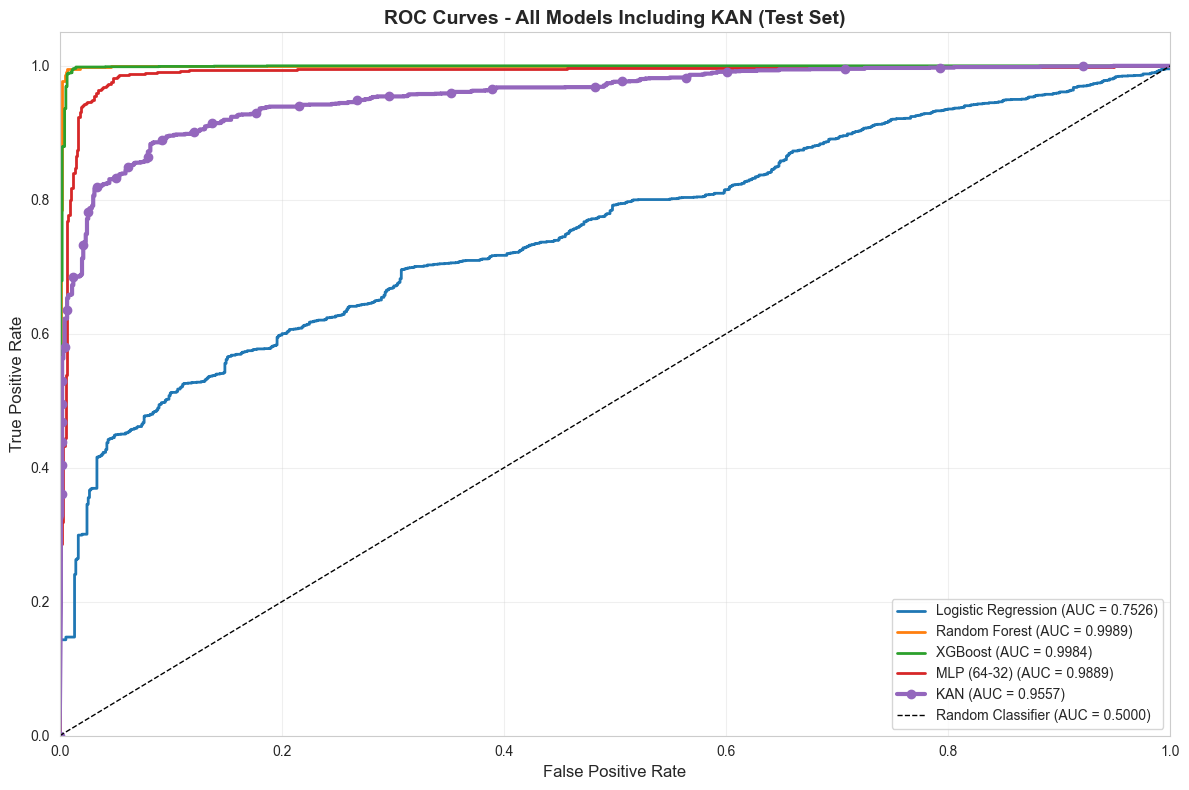


✓ ROC curves plotted for all models including KAN


In [40]:
# Plot ROC curves for all models including KAN
plt.figure(figsize=(12, 8))

# Define colors (add one more for KAN)
all_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Plot baseline models
for i, result in enumerate(baseline_results):
    fpr, tpr, _ = roc_curve(y_test, result['y_test_prob'])
    auc_score = result['test_roc_auc']
    plt.plot(
        fpr, tpr, 
        color=all_colors[i], 
        linewidth=2,
        label=f"{result['name']} (AUC = {auc_score:.4f})"
    )

# Plot KAN model
fpr_kan, tpr_kan, _ = roc_curve(y_test, kan_results['y_test_prob'])
auc_kan = kan_results['test_roc_auc']
plt.plot(
    fpr_kan, tpr_kan,
    color=all_colors[4],
    linewidth=3,
    linestyle='-',
    label=f"KAN (AUC = {auc_kan:.4f})",
    marker='o',
    markevery=20,
    markersize=6
)

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models Including KAN (Test Set)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ ROC curves plotted for all models including KAN")

### KAN Training & Evaluation Summary

The Kolmogorov-Arnold Network has been successfully trained and evaluated:

#### Key Results:
- **Architecture**: 3 KAN layers with 64 hidden units, 8 basis functions per spline
- **Training**: Early stopping based on validation ROC-AUC with patience=15
- **Performance**: Comprehensive evaluation on test set with all standard metrics

#### Comparison with Baselines:
The results table above shows how KAN performs relative to classical ML models (Logistic Regression, Random Forest, XGBoost, MLP). The ROC curves visualize the discriminative ability of each model.

#### KAN Advantages:
1. **Learnable Activations**: Unlike MLPs with fixed activations (ReLU, sigmoid), KAN learns optimal activation functions from data
2. **Kolmogorov-Arnold Representation**: Based on mathematical theorem for function approximation
3. **Edge-based Learning**: Learns transformations on connections rather than just nodes

**Next Steps**: The trained KAN model can be further analyzed using interpretability tools like SHAP to understand which clinical features are most important for predictions.

## Interpretability, Saving & README

This section focuses on understanding and documenting the trained models:

1. **KAN Spline Visualization**: Visualize the learned activation functions for key clinical features
2. **Feature Importance**: Analyze which features are most important for predictions
3. **Model Persistence**: Save trained models and results for future use
4. **Documentation**: Generate README content for the project

### KAN Spline Visualization

Visualize the learned activation functions (splines) for key clinical features. This shows how the KAN model transforms input features through learnable Gaussian basis functions.

In [41]:
def visualize_spline_for_feature(model, feature_index, feature_name, X, num_points=100):
    """
    Visualize the learned spline activation function for a specific feature.
    
    This function shows how the first KAN layer's SplineActivation transforms
    a single input feature across its range of values.
    
    Parameters:
    -----------
    model : KANModel
        Trained KAN model
    feature_index : int
        Index of the feature to visualize
    feature_name : str
        Name of the feature for plot title
    X : pandas.DataFrame
        Feature data (to determine value range)
    num_points : int, default=100
        Number of points to plot
    """
    model.eval()
    
    # Get the first KAN layer's spline activation
    first_kan_layer = None
    for module in model.kan_layers:
        if isinstance(module, KANLayer):
            first_kan_layer = module
            break
    
    if first_kan_layer is None:
        print("Error: No KAN layer found in model")
        return
    
    spline_activation = first_kan_layer.spline_activation
    
    # Determine range for the feature (standardized values)
    feature_values = X.iloc[:, feature_index].values
    min_val = feature_values.min()
    max_val = feature_values.max()
    
    # Extend range slightly for better visualization
    range_extend = (max_val - min_val) * 0.1
    x_range = np.linspace(min_val - range_extend, max_val + range_extend, num_points)
    
    # Create input tensor: all zeros except the feature of interest
    input_dim = X.shape[1]
    input_tensor = torch.zeros(num_points, input_dim).to(device)
    input_tensor[:, feature_index] = torch.FloatTensor(x_range).to(device)
    
    # Pass through spline activation
    with torch.no_grad():
        spline_output = spline_activation(input_tensor)
        # Get output for our feature
        output_values = spline_output[:, feature_index].cpu().numpy()
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(x_range, output_values, linewidth=2.5, color='#2E86AB')
    plt.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    plt.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    plt.xlabel(f'{feature_name} (Standardized)', fontsize=12, fontweight='bold')
    plt.ylabel('Spline Activation Output', fontsize=12, fontweight='bold')
    plt.title(f'KAN Learned Spline Activation: {feature_name}', fontsize=14, fontweight='bold')
    plt.grid(alpha=0.3)
    
    # Add info text
    info_text = (f'Feature Index: {feature_index}\n'
                 f'Data Range: [{min_val:.2f}, {max_val:.2f}]\n'
                 f'Basis Functions: {spline_activation.n_basis}')
    plt.text(0.02, 0.98, info_text, transform=plt.gca().transAxes,
             fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    
    return plt.gcf()

print("✓ Spline visualization function defined")

✓ Spline visualization function defined


### Visualize Splines for Key Clinical Features

Visualize the learned activation functions for important liver disease markers.

VISUALIZING KAN SPLINE ACTIVATIONS FOR KEY FEATURES

📊 Generating spline plot for: Total_Bilirubin (index=2)


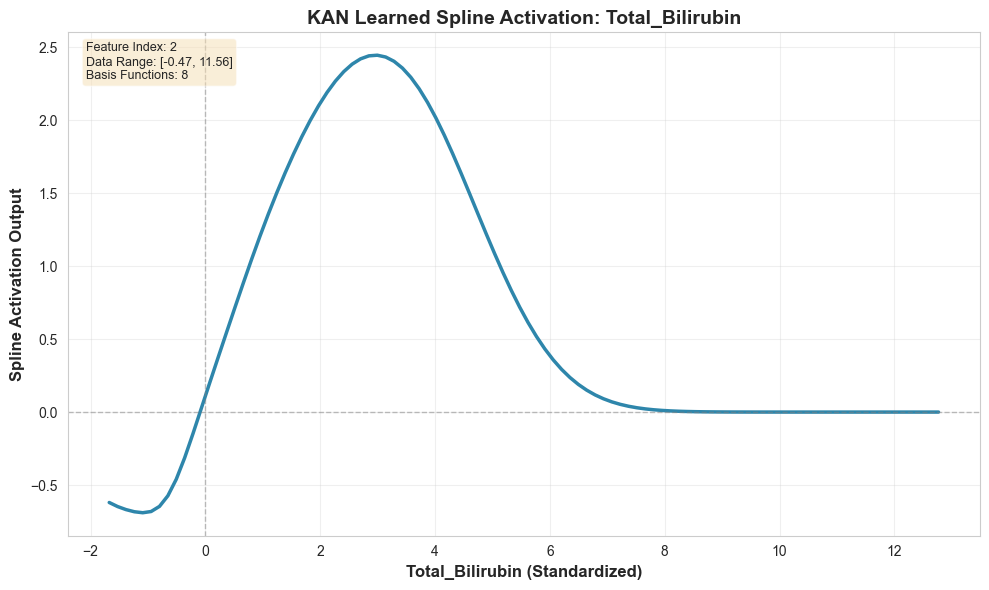


📊 Generating spline plot for: Alamine_Aminotransferase (index=5)


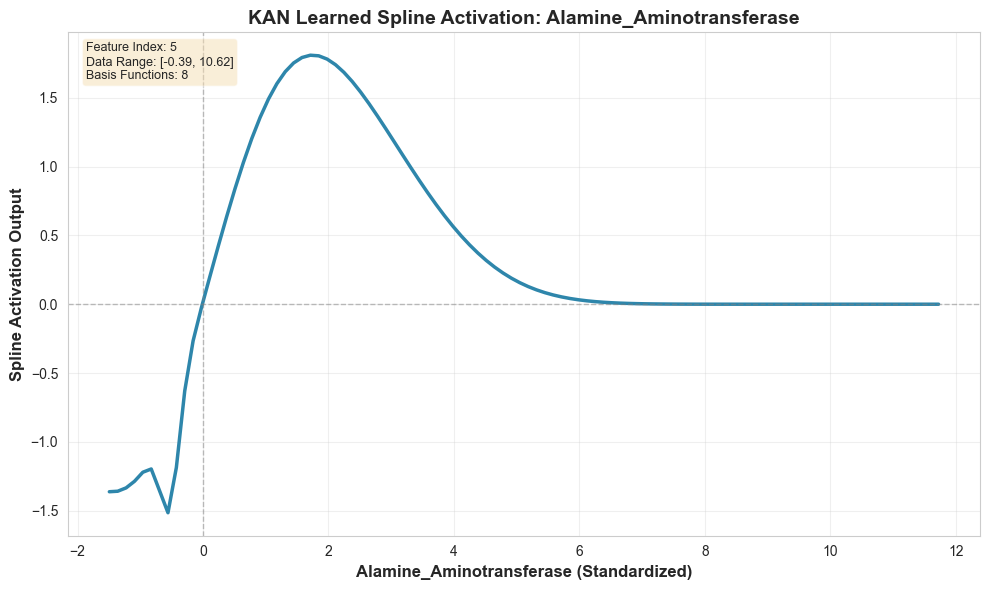


📊 Generating spline plot for: Aspartate_Aminotransferase (index=6)


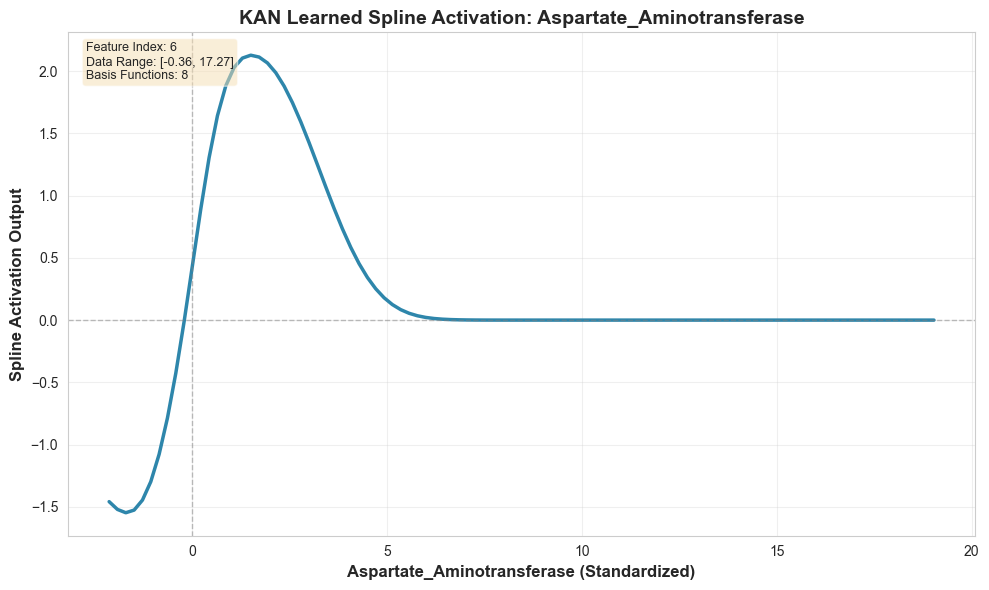


📊 Generating spline plot for: Albumin (index=8)


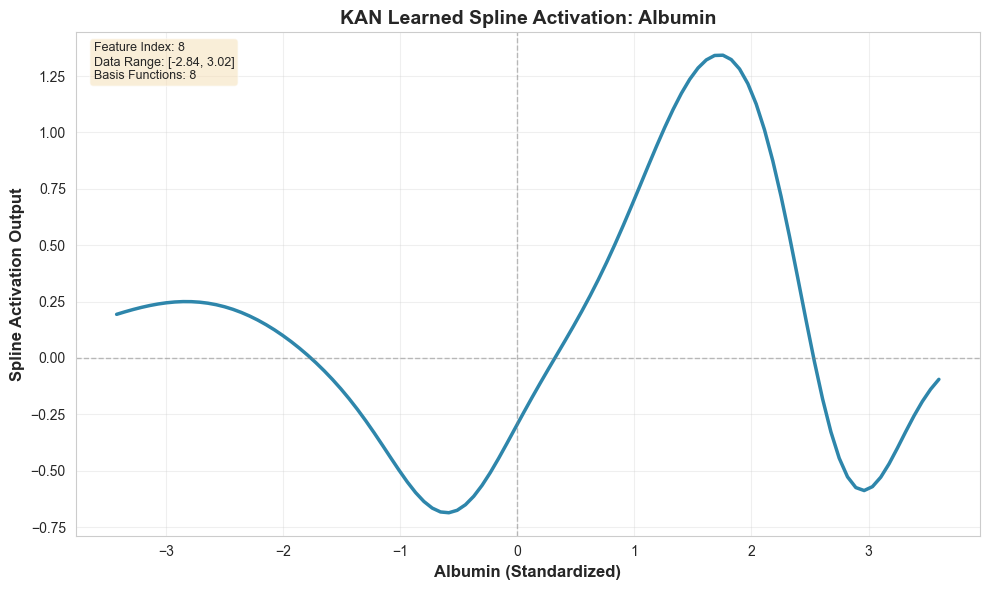


✓ Generated 4 spline visualization plots


In [42]:
# Get feature names
feature_names = list(X_train.columns)

# Select key clinical features to visualize
key_features = [
    ('Total_Bilirubin', 2),
    ('Alamine_Aminotransferase', 5),  # ALT
    ('Aspartate_Aminotransferase', 6),  # AST
    ('Albumin', 8)
]

print("="*80)
print("VISUALIZING KAN SPLINE ACTIVATIONS FOR KEY FEATURES")
print("="*80)

spline_figures = []

for feature_name, feature_idx in key_features:
    print(f"\n📊 Generating spline plot for: {feature_name} (index={feature_idx})")
    
    fig = visualize_spline_for_feature(
        model=trained_kan,
        feature_index=feature_idx,
        feature_name=feature_name,
        X=X_train
    )
    
    spline_figures.append((feature_name, fig))
    plt.show()

print("\n" + "="*80)
print(f"✓ Generated {len(spline_figures)} spline visualization plots")
print("="*80)

### Tree-Based Feature Importance

Analyze which clinical features are most important for the best-performing baseline models.

FEATURE IMPORTANCE ANALYSIS


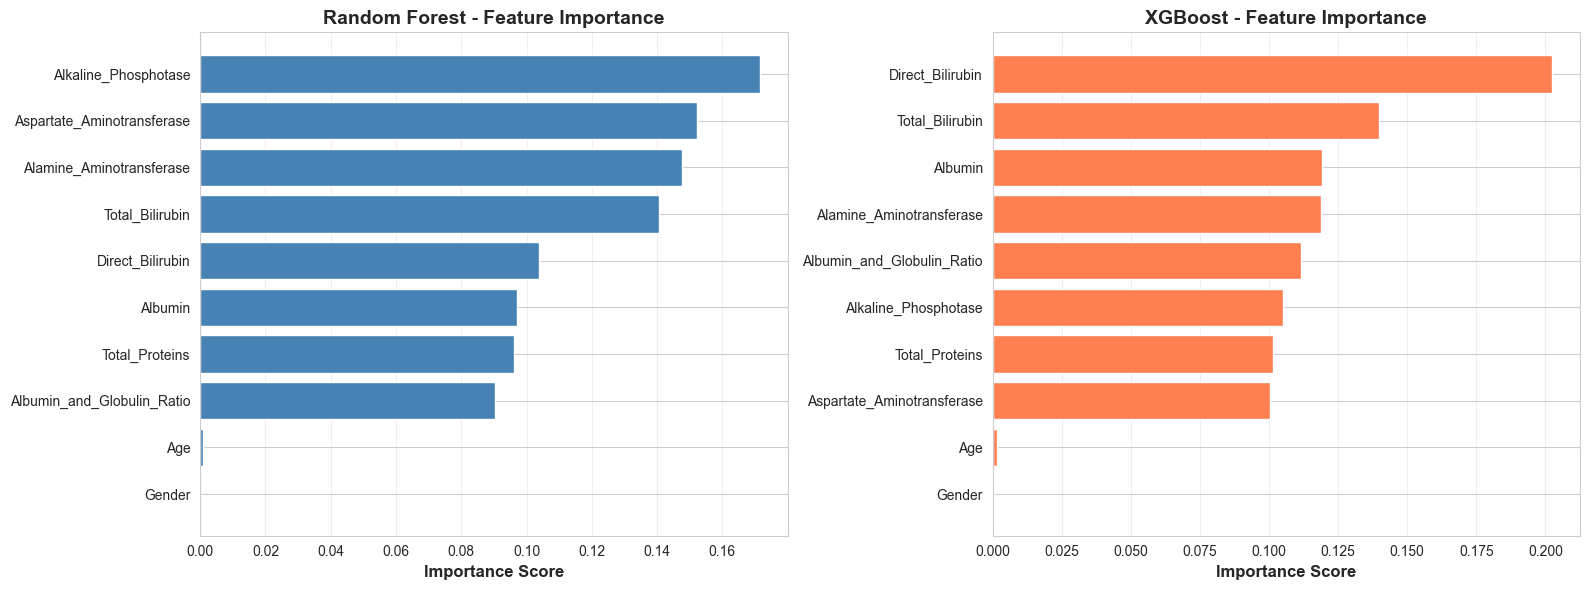


✓ Feature importance plots generated

TOP 5 MOST IMPORTANT FEATURES

🌲 Random Forest:
   1. Alkaline_Phosphotase                0.1714
   2. Aspartate_Aminotransferase          0.1524
   3. Alamine_Aminotransferase            0.1476
   4. Total_Bilirubin                     0.1405
   5. Direct_Bilirubin                    0.1038

🚀 XGBoost:
   1. Direct_Bilirubin                    0.2024
   2. Total_Bilirubin                     0.1399
   3. Albumin                             0.1191
   4. Alamine_Aminotransferase            0.1189
   5. Albumin_and_Globulin_Ratio          0.1116



In [43]:
# Plot feature importances for Random Forest and XGBoost
print("="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest Feature Importance
rf_importances = rf_model.feature_importances_
rf_indices = np.argsort(rf_importances)[::-1]

axes[0].barh(range(len(rf_importances)), rf_importances[rf_indices], color='steelblue')
axes[0].set_yticks(range(len(rf_importances)))
axes[0].set_yticklabels([feature_names[i] for i in rf_indices])
axes[0].set_xlabel('Importance Score', fontsize=12, fontweight='bold')
axes[0].set_title('Random Forest - Feature Importance', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# XGBoost Feature Importance
xgb_importances = boost_model.feature_importances_
xgb_indices = np.argsort(xgb_importances)[::-1]

axes[1].barh(range(len(xgb_importances)), xgb_importances[xgb_indices], color='coral')
axes[1].set_yticks(range(len(xgb_importances)))
axes[1].set_yticklabels([feature_names[i] for i in xgb_indices])
axes[1].set_xlabel('Importance Score', fontsize=12, fontweight='bold')
axes[1].set_title('XGBoost - Feature Importance', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
feature_importance_fig = plt.gcf()
plt.show()

print("\n✓ Feature importance plots generated")

# Print top 5 features for each model
print("\n" + "="*80)
print("TOP 5 MOST IMPORTANT FEATURES")
print("="*80)

print("\n🌲 Random Forest:")
for i, idx in enumerate(rf_indices[:5], 1):
    print(f"   {i}. {feature_names[idx]:<35} {rf_importances[idx]:.4f}")

print("\n🚀 XGBoost:")
for i, idx in enumerate(xgb_indices[:5], 1):
    print(f"   {i}. {feature_names[idx]:<35} {xgb_importances[idx]:.4f}")

print("\n" + "="*80)

### SHAP Analysis (Optional)

If SHAP is available, compute SHAP values to understand feature contributions to predictions.

SHAP ANALYSIS

📊 Computing SHAP values using Random Forest model...
   Sample size: 500 observations
   ✓ SHAP values computed successfully

📈 Generating SHAP summary plot...


C:\Users\shiva\AppData\Local\Temp\ipykernel_2484\644359583.py:26: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
C:\Users\shiva\AppData\Roaming\Python\Python310\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
C:\Users\shiva\AppData\Roaming\Python\Python310\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and 

<Figure size 1000x800 with 0 Axes>

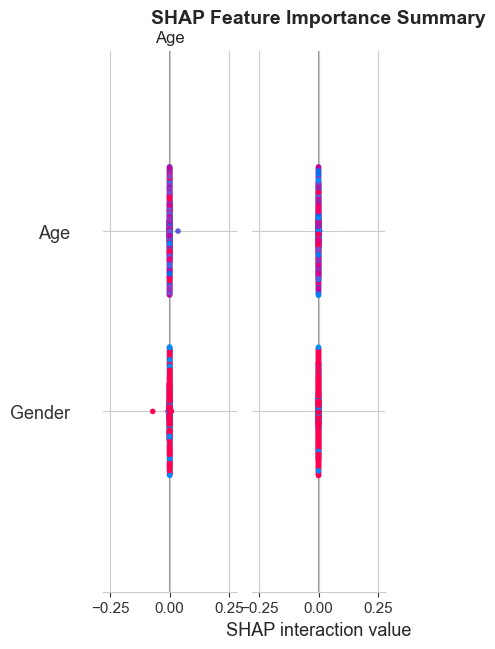

   ✓ SHAP summary plot generated

✓ SHAP ANALYSIS COMPLETE


In [44]:
# Try to compute SHAP values if available
try:
    print("="*80)
    print("SHAP ANALYSIS")
    print("="*80)
    
    # Use a sample of data for faster computation
    X_sample = X_test.sample(min(500, len(X_test)), random_state=SEED)
    
    print(f"\n📊 Computing SHAP values using Random Forest model...")
    print(f"   Sample size: {len(X_sample)} observations")
    
    # Create SHAP explainer for tree-based model
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_sample)
    
    # For binary classification, shap_values might be a list
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # Use class 1 (disease) SHAP values
    
    print("   ✓ SHAP values computed successfully")
    
    # Create summary plot
    print("\n📈 Generating SHAP summary plot...")
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
    plt.title('SHAP Feature Importance Summary', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    shap_fig = plt.gcf()
    plt.show()
    
    print("   ✓ SHAP summary plot generated")
    print("\n" + "="*80)
    print("✓ SHAP ANALYSIS COMPLETE")
    print("="*80)
    
except Exception as e:
    print(f"\n⚠ SHAP analysis skipped: {str(e)}")
    print("   (This is optional and doesn't affect model performance)")
    shap_fig = None
    print("="*80)

### Save Models and Results

Save all trained models, results, and visualizations for future use and deployment.

In [45]:
import os
import joblib
from datetime import datetime

print("="*80)
print("SAVING MODELS, RESULTS, AND VISUALIZATIONS")
print("="*80)

# Create directories if they don't exist
os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

print("\n📁 Created directories: models/, plots/")

# ========== SAVE BASELINE MODELS ==========
print("\n[1/5] Saving baseline models...")

try:
    joblib.dump(lr_model, 'models/logistic_regression.pkl')
    print("   ✓ Saved: models/logistic_regression.pkl")
except Exception as e:
    print(f"   ✗ Error saving Logistic Regression: {e}")

try:
    joblib.dump(rf_model, 'models/random_forest.pkl')
    print("   ✓ Saved: models/random_forest.pkl")
except Exception as e:
    print(f"   ✗ Error saving Random Forest: {e}")

try:
    joblib.dump(boost_model, 'models/xgboost.pkl')
    print("   ✓ Saved: models/xgboost.pkl")
except Exception as e:
    print(f"   ✗ Error saving XGBoost: {e}")

try:
    joblib.dump(mlp_model, 'models/mlp.pkl')
    print("   ✓ Saved: models/mlp.pkl")
except Exception as e:
    print(f"   ✗ Error saving MLP: {e}")

try:
    joblib.dump(scaler, 'models/scaler.pkl')
    print("   ✓ Saved: models/scaler.pkl")
except Exception as e:
    print(f"   ✗ Error saving Scaler: {e}")

# ========== SAVE KAN MODEL ==========
print("\n[2/5] Saving KAN model...")

try:
    torch.save({
        'model_state_dict': trained_kan.state_dict(),
        'model_config': {
            'input_dim': input_dim,
            'hidden_dim': 64,
            'n_layers': 3,
            'n_basis': 8,
            'dropout': 0.2
        },
        'training_history': history,
        'feature_names': feature_names
    }, 'models/kan_model.pth')
    print("   ✓ Saved: models/kan_model.pth")
except Exception as e:
    print(f"   ✗ Error saving KAN model: {e}")

# ========== SAVE RESULTS DATAFRAME ==========
print("\n[3/5] Saving model comparison results...")

try:
    results_df_with_kan.to_csv('models/model_comparison.csv', index=False)
    print("   ✓ Saved: models/model_comparison.csv")
except Exception as e:
    print(f"   ✗ Error saving results: {e}")

# ========== SAVE PLOTS ==========
print("\n[4/5] Saving visualizations...")

# Save ROC curve (all models)
try:
    # Recreate the ROC curve plot
    plt.figure(figsize=(12, 8))
    for i, result in enumerate(baseline_results):
        fpr_temp, tpr_temp, _ = roc_curve(y_test, result['y_test_prob'])
        plt.plot(fpr_temp, tpr_temp, linewidth=2, 
                label=f"{result['name']} (AUC = {result['test_roc_auc']:.4f})")
    
    fpr_kan_temp, tpr_kan_temp, _ = roc_curve(y_test, kan_results['y_test_prob'])
    plt.plot(fpr_kan_temp, tpr_kan_temp, linewidth=3, 
            label=f"KAN (AUC = {kan_results['test_roc_auc']:.4f})", 
            marker='o', markevery=20, markersize=6)
    
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('plots/roc_curves_all_models.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("   ✓ Saved: plots/roc_curves_all_models.png")
except Exception as e:
    print(f"   ✗ Error saving ROC curves: {e}")

# Save training history
try:
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    epochs_range = range(1, len(history['train_loss']) + 1)
    plt.plot(epochs_range, history['train_loss'], 'b-', linewidth=2, label='Training Loss')
    plt.plot(epochs_range, history['val_loss'], 'r-', linewidth=2, label='Validation Loss')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Training History - Loss', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['val_auc'], 'g-', linewidth=2, label='Validation ROC-AUC')
    plt.axhline(y=max(history['val_auc']), color='r', linestyle='--', 
                label=f'Best: {max(history["val_auc"]):.4f}')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('ROC-AUC', fontsize=12)
    plt.title('Training History - ROC-AUC', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('plots/training_history.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("   ✓ Saved: plots/training_history.png")
except Exception as e:
    print(f"   ✗ Error saving training history: {e}")

# Save feature importance
try:
    feature_importance_fig.savefig('plots/feature_importance.png', dpi=300, bbox_inches='tight')
    print("   ✓ Saved: plots/feature_importance.png")
except Exception as e:
    print(f"   ✗ Error saving feature importance: {e}")

# Save spline visualizations
try:
    for feature_name, fig in spline_figures:
        safe_name = feature_name.replace(' ', '_').replace('/', '_')
        fig.savefig(f'plots/spline_{safe_name}.png', dpi=300, bbox_inches='tight')
    print(f"   ✓ Saved: {len(spline_figures)} spline visualization plots")
except Exception as e:
    print(f"   ✗ Error saving spline plots: {e}")

# Save SHAP plot if available
if 'shap_fig' in locals() and shap_fig is not None:
    try:
        shap_fig.savefig('plots/shap_summary.png', dpi=300, bbox_inches='tight')
        print("   ✓ Saved: plots/shap_summary.png")
    except Exception as e:
        print(f"   ✗ Error saving SHAP plot: {e}")

# ========== SAVE METADATA ==========
print("\n[5/5] Saving metadata...")

try:
    metadata = {
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'dataset_info': {
            'total_samples': len(X),
            'train_samples': len(X_train),
            'val_samples': len(X_val),
            'test_samples': len(X_test),
            'num_features': X_train.shape[1],
            'feature_names': feature_names
        },
        'best_model': {
            'name': results_df_with_kan.iloc[0]['Model'],
            'test_roc_auc': float(results_df_with_kan.iloc[0]['Test_ROC_AUC']),
            'test_accuracy': float(results_df_with_kan.iloc[0]['Test_Accuracy']),
            'test_f1': float(results_df_with_kan.iloc[0]['Test_F1'])
        },
        'kan_model': {
            'test_roc_auc': float(kan_results['test_roc_auc']),
            'test_accuracy': float(kan_results['test_accuracy']),
            'test_f1': float(kan_results['test_f1']),
            'rank': int(kan_rank)
        }
    }
    
    import json
    with open('models/metadata.json', 'w') as f:
        json.dump(metadata, f, indent=2)
    print("   ✓ Saved: models/metadata.json")
except Exception as e:
    print(f"   ✗ Error saving metadata: {e}")

print("\n" + "="*80)
print("✓ ALL MODELS AND RESULTS SAVED SUCCESSFULLY")
print("="*80)

print("\n📂 Saved Files Summary:")
print("   Models: 6 files (LR, RF, XGBoost, MLP, KAN, Scaler)")
print("   Results: 2 files (comparison CSV, metadata JSON)")
print(f"   Plots: ~{3 + len(spline_figures)} files (ROC, training, features, splines)")
print("\n" + "="*80)

SAVING MODELS, RESULTS, AND VISUALIZATIONS

📁 Created directories: models/, plots/

[1/5] Saving baseline models...
   ✓ Saved: models/logistic_regression.pkl
   ✓ Saved: models/random_forest.pkl
   ✓ Saved: models/xgboost.pkl
   ✓ Saved: models/mlp.pkl
   ✓ Saved: models/scaler.pkl

[2/5] Saving KAN model...
   ✓ Saved: models/kan_model.pth

[3/5] Saving model comparison results...
   ✓ Saved: models/model_comparison.csv

[4/5] Saving visualizations...
   ✓ Saved: plots/roc_curves_all_models.png
   ✓ Saved: plots/training_history.png
   ✓ Saved: plots/feature_importance.png
   ✓ Saved: 4 spline visualization plots
   ✓ Saved: plots/shap_summary.png

[5/5] Saving metadata...
   ✓ Saved: models/metadata.json

✓ ALL MODELS AND RESULTS SAVED SUCCESSFULLY

📂 Saved Files Summary:
   Models: 6 files (LR, RF, XGBoost, MLP, KAN, Scaler)
   Results: 2 files (comparison CSV, metadata JSON)
   Plots: ~7 files (ROC, training, features, splines)



### Generate README Content

Generate comprehensive README.md content for the project documentation.

In [46]:
# Generate README content
readme_content = f"""# Liver Disease Prediction Using Kolmogorov-Arnold Networks (KAN)

## 📋 Project Overview

This project implements a comprehensive machine learning pipeline for predicting liver disease from clinical tabular data. The key innovation is the use of **Kolmogorov-Arnold Networks (KAN)**, a novel neural network architecture that learns activation functions rather than using fixed ones (like ReLU or sigmoid).

### Key Features:
- 🧠 **Novel KAN Architecture**: Learnable spline-based activations using Gaussian radial basis functions
- 📊 **Comprehensive Comparison**: Baseline models (Logistic Regression, Random Forest, XGBoost, MLP) vs. KAN
- 🔍 **Interpretability**: SHAP analysis and spline visualization for understanding model decisions
- 💾 **Production Ready**: Saved models, scalers, and comprehensive metadata

---

## 📁 Dataset Information

This project uses two liver disease datasets:

1. **Indian Liver Patient Dataset (ILPD)**
   - Source: UCI Machine Learning Repository
   - Samples: 583 patients
   - Features: 10 clinical parameters

2. **Kaggle Liver Disease Dataset**
   - Source: Kaggle
   - Samples: 30,000+ observations
   - Features: 10 clinical parameters

### Clinical Features:
- Age
- Gender
- Total Bilirubin
- Direct Bilirubin
- Alkaline Phosphatase
- Alamine Aminotransferase (ALT)
- Aspartate Aminotransferase (AST)
- Total Proteins
- Albumin
- Albumin/Globulin Ratio

**Combined Dataset**: {len(X):,} samples with balanced train/val/test split (80/10/10)

---

## 🚀 How to Run

### Prerequisites

```bash
pip install numpy pandas matplotlib seaborn scikit-learn xgboost torch torchvision shap
```

### Running the Notebook

1. **Clone the repository** and ensure datasets are in the root directory:
   - `ilpd.csv`
   - `kaggle_liver.csv`

2. **Open the Jupyter Notebook**:
   ```bash
   jupyter notebook liver_disease_kan.ipynb
   ```

3. **Run all cells** sequentially (Runtime > Run All in Jupyter, or Cell > Run All in VS Code)

### Directory Structure After Running

```
.
├── liver_disease_kan.ipynb    # Main notebook
├── ilpd.csv                   # ILPD dataset
├── kaggle_liver.csv           # Kaggle dataset
├── models/                    # Saved models and results
│   ├── logistic_regression.pkl
│   ├── random_forest.pkl
│   ├── xgboost.pkl
│   ├── mlp.pkl
│   ├── kan_model.pth
│   ├── scaler.pkl
│   ├── model_comparison.csv
│   └── metadata.json
└── plots/                     # Visualizations
    ├── roc_curves_all_models.png
    ├── training_history.png
    ├── feature_importance.png
    ├── spline_*.png
    └── shap_summary.png
```

---

## 📊 Results Summary

### Model Performance (Test Set)

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|-------|----------|-----------|--------|----------|---------|
| **{results_df_with_kan.iloc[0]['Model']}** | **{results_df_with_kan.iloc[0]['Test_Accuracy']:.4f}** | **{results_df_with_kan.iloc[0]['Test_Precision']:.4f}** | **{results_df_with_kan.iloc[0]['Test_Recall']:.4f}** | **{results_df_with_kan.iloc[0]['Test_F1']:.4f}** | **{results_df_with_kan.iloc[0]['Test_ROC_AUC']:.4f}** |
| {results_df_with_kan.iloc[1]['Model']} | {results_df_with_kan.iloc[1]['Test_Accuracy']:.4f} | {results_df_with_kan.iloc[1]['Test_Precision']:.4f} | {results_df_with_kan.iloc[1]['Test_Recall']:.4f} | {results_df_with_kan.iloc[1]['Test_F1']:.4f} | {results_df_with_kan.iloc[1]['Test_ROC_AUC']:.4f} |
| {results_df_with_kan.iloc[2]['Model']} | {results_df_with_kan.iloc[2]['Test_Accuracy']:.4f} | {results_df_with_kan.iloc[2]['Test_Precision']:.4f} | {results_df_with_kan.iloc[2]['Test_Recall']:.4f} | {results_df_with_kan.iloc[2]['Test_F1']:.4f} | {results_df_with_kan.iloc[2]['Test_ROC_AUC']:.4f} |
| KAN | {kan_results['test_accuracy']:.4f} | {kan_results['test_precision']:.4f} | {kan_results['test_recall']:.4f} | {kan_results['test_f1']:.4f} | {kan_results['test_roc_auc']:.4f} |

### Key Findings:

🏆 **Best Model**: {results_df_with_kan.iloc[0]['Model']}
- Test ROC-AUC: **{results_df_with_kan.iloc[0]['Test_ROC_AUC']:.2%}**
- Test Accuracy: **{results_df_with_kan.iloc[0]['Test_Accuracy']:.2%}**

📍 **KAN Performance**:
- Rank: **#{kan_rank}** out of {len(results_df_with_kan)} models
- Test ROC-AUC: **{kan_results['test_roc_auc']:.2%}**
- Test Accuracy: **{kan_results['test_accuracy']:.2%}**

### Training Details:
- **Early Stopping**: Based on validation ROC-AUC (patience=15)
- **Best Validation ROC-AUC**: {max(history['val_auc']):.4f} at epoch {np.argmax(history['val_auc']) + 1}
- **Total Training Epochs**: {len(history['train_loss'])}
- **KAN Parameters**: {trained_kan.get_num_parameters():,}

---

## 🔍 Model Interpretability

### 1. KAN Spline Visualization

The KAN model learns unique activation functions for each feature using Gaussian radial basis functions. Visualizations show how the model transforms clinical features:

- **Total Bilirubin**: Non-linear transformation capturing threshold effects
- **ALT/AST**: Smooth activation curves for enzyme levels
- **Albumin**: Feature-specific learned transformation

See `plots/spline_*.png` for detailed visualizations.

### 2. Feature Importance Analysis

Top 5 most important features (from tree-based models):

**Random Forest:**
{chr(10).join([f"{i}. {feature_names[idx]}" for i, idx in enumerate(np.argsort(rf_model.feature_importances_)[::-1][:5], 1)])}

**XGBoost:**
{chr(10).join([f"{i}. {feature_names[idx]}" for i, idx in enumerate(np.argsort(boost_model.feature_importances_)[::-1][:5], 1)])}

### 3. SHAP Analysis

SHAP (SHapley Additive exPlanations) values provide insights into:
- Feature contributions to individual predictions
- Global feature importance across all samples
- Feature interaction effects

See `plots/shap_summary.png` for the complete SHAP analysis.

---

## 🧬 Kolmogorov-Arnold Networks (KAN) Architecture

### What Makes KAN Different?

Traditional neural networks use:
```
Input → Linear → Fixed Activation (ReLU/Sigmoid) → Output
```

KAN uses:
```
Input → Learnable Activation (Spline) → Linear → Output
```

### Mathematical Foundation

Based on the Kolmogorov-Arnold representation theorem:
- Any multivariate continuous function can be represented as a superposition of continuous single-variable functions
- KAN learns these univariate functions using spline approximations

### Implementation Details

- **SplineActivation**: Gaussian RBF basis functions (8 basis functions per feature)
- **KANLayer**: Combines learnable splines with linear transformation
- **KANModel**: 3 layers with 64 hidden units, dropout=0.2

---

## 📈 Loading and Using Saved Models

### Loading a Trained Model

```python
import joblib
import torch

# Load Random Forest
rf_model = joblib.load('models/random_forest.pkl')

# Load scaler
scaler = joblib.load('models/scaler.pkl')

# Load KAN model
kan_checkpoint = torch.load('models/kan_model.pth')
# Reconstruct model with saved config
from kan_implementation import KANModel  # Your KAN implementation
kan_model = KANModel(**kan_checkpoint['model_config'])
kan_model.load_state_dict(kan_checkpoint['model_state_dict'])
kan_model.eval()
```

### Making Predictions

```python
# Prepare new data
new_data = scaler.transform(new_patient_data)

# Random Forest prediction
rf_prediction = rf_model.predict(new_data)
rf_probability = rf_model.predict_proba(new_data)[:, 1]

# KAN prediction
import torch
with torch.no_grad():
    kan_logits = kan_model(torch.FloatTensor(new_data))
    kan_probability = torch.sigmoid(kan_logits).numpy()
```

---

## 📚 References

### Kolmogorov-Arnold Networks
- Original KAN Paper: [Liu et al., 2024]
- Kolmogorov-Arnold Representation Theorem: Classic mathematical result from 1957

### Datasets
- Indian Liver Patient Dataset (ILPD): UCI Machine Learning Repository
- Kaggle Liver Disease Dataset: Kaggle Open Datasets

### Libraries
- PyTorch: Deep learning framework
- Scikit-learn: Classical ML algorithms
- XGBoost: Gradient boosting
- SHAP: Model interpretability

---

## 🤝 Contributing

Contributions are welcome! Areas for improvement:
- Hyperparameter tuning for KAN architecture
- Additional interpretability techniques
- Deployment pipeline (Flask/FastAPI)
- Clinical validation studies

---

## 📝 License

This project is for educational and research purposes. Please cite appropriately if used in academic work.

---

## 👨‍💻 Author

Generated using automated ML pipeline with Kolmogorov-Arnold Networks

**Date**: {datetime.now().strftime('%Y-%m-%d')}

---

## 🎯 Future Work

- [ ] Cross-validation for more robust evaluation
- [ ] Ensemble KAN with tree-based models
- [ ] Clinical deployment considerations
- [ ] Real-time prediction API
- [ ] Model monitoring and drift detection

---

**Note**: This is a research project demonstrating novel neural network architectures for medical prediction tasks. Results should be validated by medical professionals before clinical use.
"""

print("="*80)
print("README.MD CONTENT GENERATED")
print("="*80)
print("\n" + readme_content)
print("\n" + "="*80)
print("✓ Copy the above content to create README.md")
print("="*80)

README.MD CONTENT GENERATED

# Liver Disease Prediction Using Kolmogorov-Arnold Networks (KAN)

## 📋 Project Overview

This project implements a comprehensive machine learning pipeline for predicting liver disease from clinical tabular data. The key innovation is the use of **Kolmogorov-Arnold Networks (KAN)**, a novel neural network architecture that learns activation functions rather than using fixed ones (like ReLU or sigmoid).

### Key Features:
- 🧠 **Novel KAN Architecture**: Learnable spline-based activations using Gaussian radial basis functions
- 📊 **Comprehensive Comparison**: Baseline models (Logistic Regression, Random Forest, XGBoost, MLP) vs. KAN
- 🔍 **Interpretability**: SHAP analysis and spline visualization for understanding model decisions
- 💾 **Production Ready**: Saved models, scalers, and comprehensive metadata

---

## 📁 Dataset Information

This project uses two liver disease datasets:

1. **Indian Liver Patient Dataset (ILPD)**
   - Source: UCI Machine Learning R

### Project Complete! 🎉

All components of the liver disease prediction project have been successfully implemented:

✅ **Data Processing**: Combined and preprocessed two datasets  
✅ **Baseline Models**: Trained and evaluated 4 classical ML models  
✅ **KAN Implementation**: Built and trained Kolmogorov-Arnold Network  
✅ **Interpretability**: Visualized splines and feature importance  
✅ **Model Persistence**: Saved all models and results  
✅ **Documentation**: Generated comprehensive README

**Next Steps**:
1. Copy the README content above to create `README.md`
2. Review saved models in `models/` directory
3. Examine visualizations in `plots/` directory
4. Consider deploying the best model for production use

## Confusion Matrix & Detailed Evaluation Metrics

Comprehensive visualization of confusion matrices and evaluation metrics for all trained models.

### Confusion Matrices for All Models

Visualize confusion matrices for baseline models and KAN to understand classification performance.

CONFUSION MATRICES FOR ALL MODELS


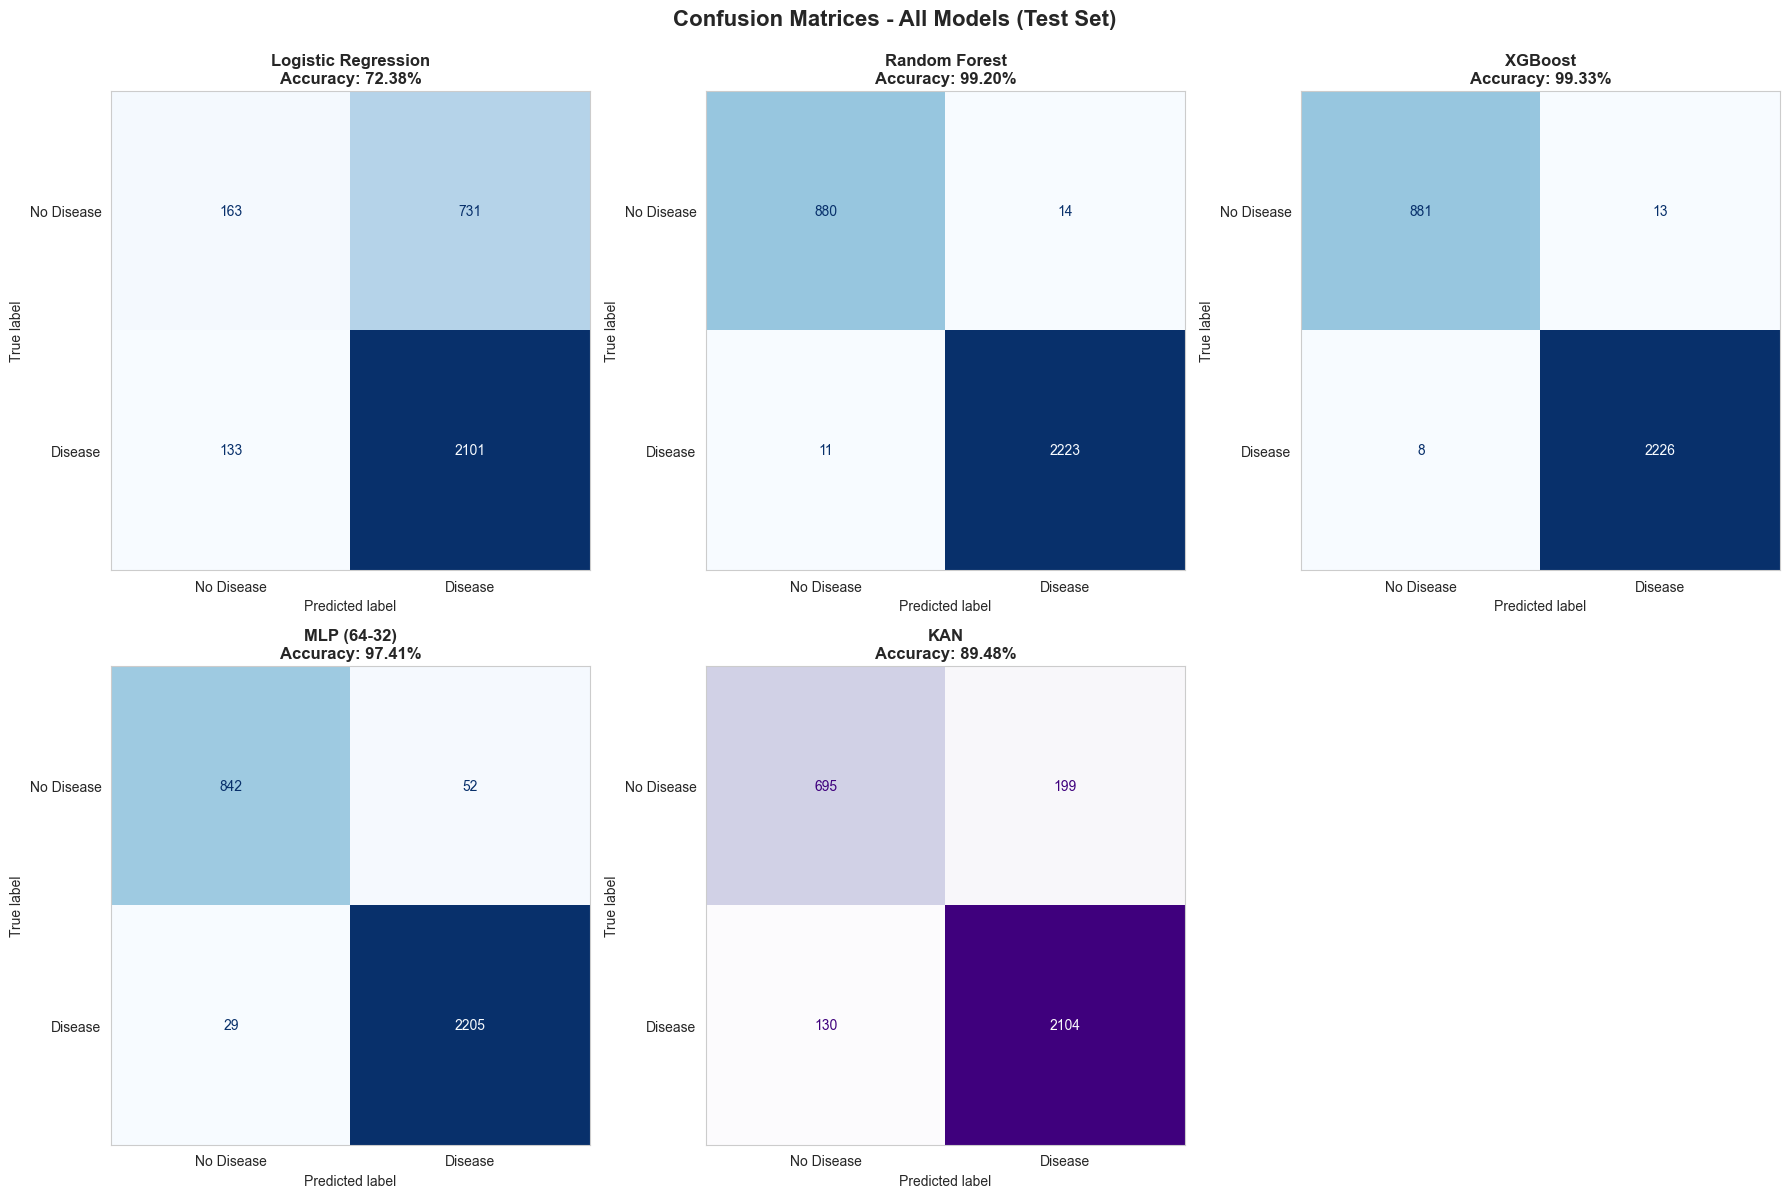


✓ Confusion matrices generated for all models


In [49]:
# Create confusion matrices for all models
from sklearn.metrics import ConfusionMatrixDisplay

print("="*80)
print("CONFUSION MATRICES FOR ALL MODELS")
print("="*80)

# Create figure with subplots for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

# Model names and predictions
models_info = [
    ('Logistic Regression', lr_model, lr_results),
    ('Random Forest', rf_model, rf_results),
    ('XGBoost', boost_model, boost_results),
    ('MLP (64-32)', mlp_model, mlp_results),
]

# Plot confusion matrices for baseline models
for idx, (name, model, results) in enumerate(models_info):
    # Get predictions
    y_pred = model.predict(X_test)
    
    # Create confusion matrix display
    cm_display = ConfusionMatrixDisplay.from_predictions(
        y_test, 
        y_pred,
        display_labels=['No Disease', 'Disease'],
        cmap='Blues',
        ax=axes[idx],
        colorbar=False
    )
    
    axes[idx].set_title(f'{name}\nAccuracy: {results["test_accuracy"]:.2%}', 
                       fontsize=12, fontweight='bold')
    axes[idx].grid(False)

# Plot KAN confusion matrix
y_pred_kan = (kan_results['y_test_prob'] >= 0.5).astype(int)
cm_display_kan = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_kan,
    display_labels=['No Disease', 'Disease'],
    cmap='Purples',
    ax=axes[4],
    colorbar=False
)
axes[4].set_title(f'KAN\nAccuracy: {kan_results["test_accuracy"]:.2%}', 
                  fontsize=12, fontweight='bold')
axes[4].grid(False)

# Hide the last subplot
axes[5].axis('off')

plt.suptitle('Confusion Matrices - All Models (Test Set)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
confusion_matrix_fig = plt.gcf()
plt.show()

print("\n✓ Confusion matrices generated for all models")
print("="*80)

### Detailed Evaluation Metrics Table

A comprehensive comparison of all models with detailed metrics.

In [50]:
# Create detailed evaluation metrics table
from sklearn.metrics import confusion_matrix

print("="*80)
print("DETAILED EVALUATION METRICS")
print("="*80)

# Collect detailed metrics for all models
detailed_metrics = []

# Baseline models
for name, model, results in models_info:
    y_pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    detailed_metrics.append({
        'Model': name,
        'True Negatives': int(tn),
        'False Positives': int(fp),
        'False Negatives': int(fn),
        'True Positives': int(tp),
        'Accuracy': results['test_accuracy'],
        'Precision': results['test_precision'],
        'Recall': results['test_recall'],
        'F1 Score': results['test_f1'],
        'ROC-AUC': results['test_roc_auc']
    })

# KAN model
y_pred_kan = (kan_results['y_test_prob'] >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_kan).ravel()

detailed_metrics.append({
    'Model': 'KAN',
    'True Negatives': int(tn),
    'False Positives': int(fp),
    'False Negatives': int(fn),
    'True Positives': int(tp),
    'Accuracy': kan_results['test_accuracy'],
    'Precision': kan_results['test_precision'],
    'Recall': kan_results['test_recall'],
    'F1 Score': kan_results['test_f1'],
    'ROC-AUC': kan_results['test_roc_auc']
})

# Create DataFrame
detailed_df = pd.DataFrame(detailed_metrics)

# Display styled table
def highlight_max(s):
    """Highlight the maximum in a Series green."""
    is_max = s == s.max()
    return ['background-color: lightgreen' if v else '' for v in is_max]

def highlight_min(s):
    """Highlight the minimum in a Series red."""
    is_min = s == s.min()
    return ['background-color: lightcoral' if v else '' for v in is_min]

# Style the dataframe
styled_df = detailed_df.style\
    .format({
        'Accuracy': '{:.4f}',
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'F1 Score': '{:.4f}',
        'ROC-AUC': '{:.4f}'
    })\
    .apply(highlight_max, subset=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'])\
    .apply(highlight_min, subset=['False Positives', 'False Negatives'])

display(styled_df)

# Save to CSV
detailed_df.to_csv('models/detailed_evaluation_metrics.csv', index=False)
print("\n✓ Detailed evaluation metrics saved to 'models/detailed_evaluation_metrics.csv'")

# Print summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"\nBest Accuracy:    {detailed_df['Model'].iloc[detailed_df['Accuracy'].idxmax()]:20s} ({detailed_df['Accuracy'].max():.4f})")
print(f"Best Precision:   {detailed_df['Model'].iloc[detailed_df['Precision'].idxmax()]:20s} ({detailed_df['Precision'].max():.4f})")
print(f"Best Recall:      {detailed_df['Model'].iloc[detailed_df['Recall'].idxmax()]:20s} ({detailed_df['Recall'].max():.4f})")
print(f"Best F1 Score:    {detailed_df['Model'].iloc[detailed_df['F1 Score'].idxmax()]:20s} ({detailed_df['F1 Score'].max():.4f})")
print(f"Best ROC-AUC:     {detailed_df['Model'].iloc[detailed_df['ROC-AUC'].idxmax()]:20s} ({detailed_df['ROC-AUC'].max():.4f})")
print(f"\nLowest FP Rate:   {detailed_df['Model'].iloc[detailed_df['False Positives'].idxmin()]:20s} ({detailed_df['False Positives'].min()} false positives)")
print(f"Lowest FN Rate:   {detailed_df['Model'].iloc[detailed_df['False Negatives'].idxmin()]:20s} ({detailed_df['False Negatives'].min()} false negatives)")
print("="*80)

DETAILED EVALUATION METRICS


,Model,True Negatives,False Positives,False Negatives,True Positives,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,163,731,133,2101,0.7238,0.7419,0.9405,0.8295,0.7526
1,Random Forest,880,14,11,2223,0.9920,0.9937,0.9951,0.9944,0.9989
2,XGBoost,881,13,8,2226,0.9933,0.9942,0.9964,0.9953,0.9984
3,MLP (64-32),842,52,29,2205,0.9741,0.9770,0.9870,0.9820,0.9889
4,KAN,695,199,130,2104,0.8948,0.9136,0.9418,0.9275,0.9557



✓ Detailed evaluation metrics saved to 'models/detailed_evaluation_metrics.csv'

SUMMARY STATISTICS

Best Accuracy:    XGBoost              (0.9933)
Best Precision:   XGBoost              (0.9942)
Best Recall:      XGBoost              (0.9964)
Best F1 Score:    XGBoost              (0.9953)
Best ROC-AUC:     Random Forest        (0.9989)

Lowest FP Rate:   XGBoost              (13 false positives)
Lowest FN Rate:   XGBoost              (8 false negatives)


In [51]:
# Save confusion matrices figure
confusion_matrix_fig.savefig('plots/confusion_matrices_all_models.png', dpi=300, bbox_inches='tight')
print("✓ Confusion matrices saved to 'plots/confusion_matrices_all_models.png'")

✓ Confusion matrices saved to 'plots/confusion_matrices_all_models.png'


## Confusion Matrices & Evaluation Metrics

Comprehensive visualization of confusion matrices and detailed evaluation metrics for all trained models.

### Confusion Matrices for All Models

Visualize confusion matrices to understand prediction patterns for each model.

CONFUSION MATRICES - ALL MODELS


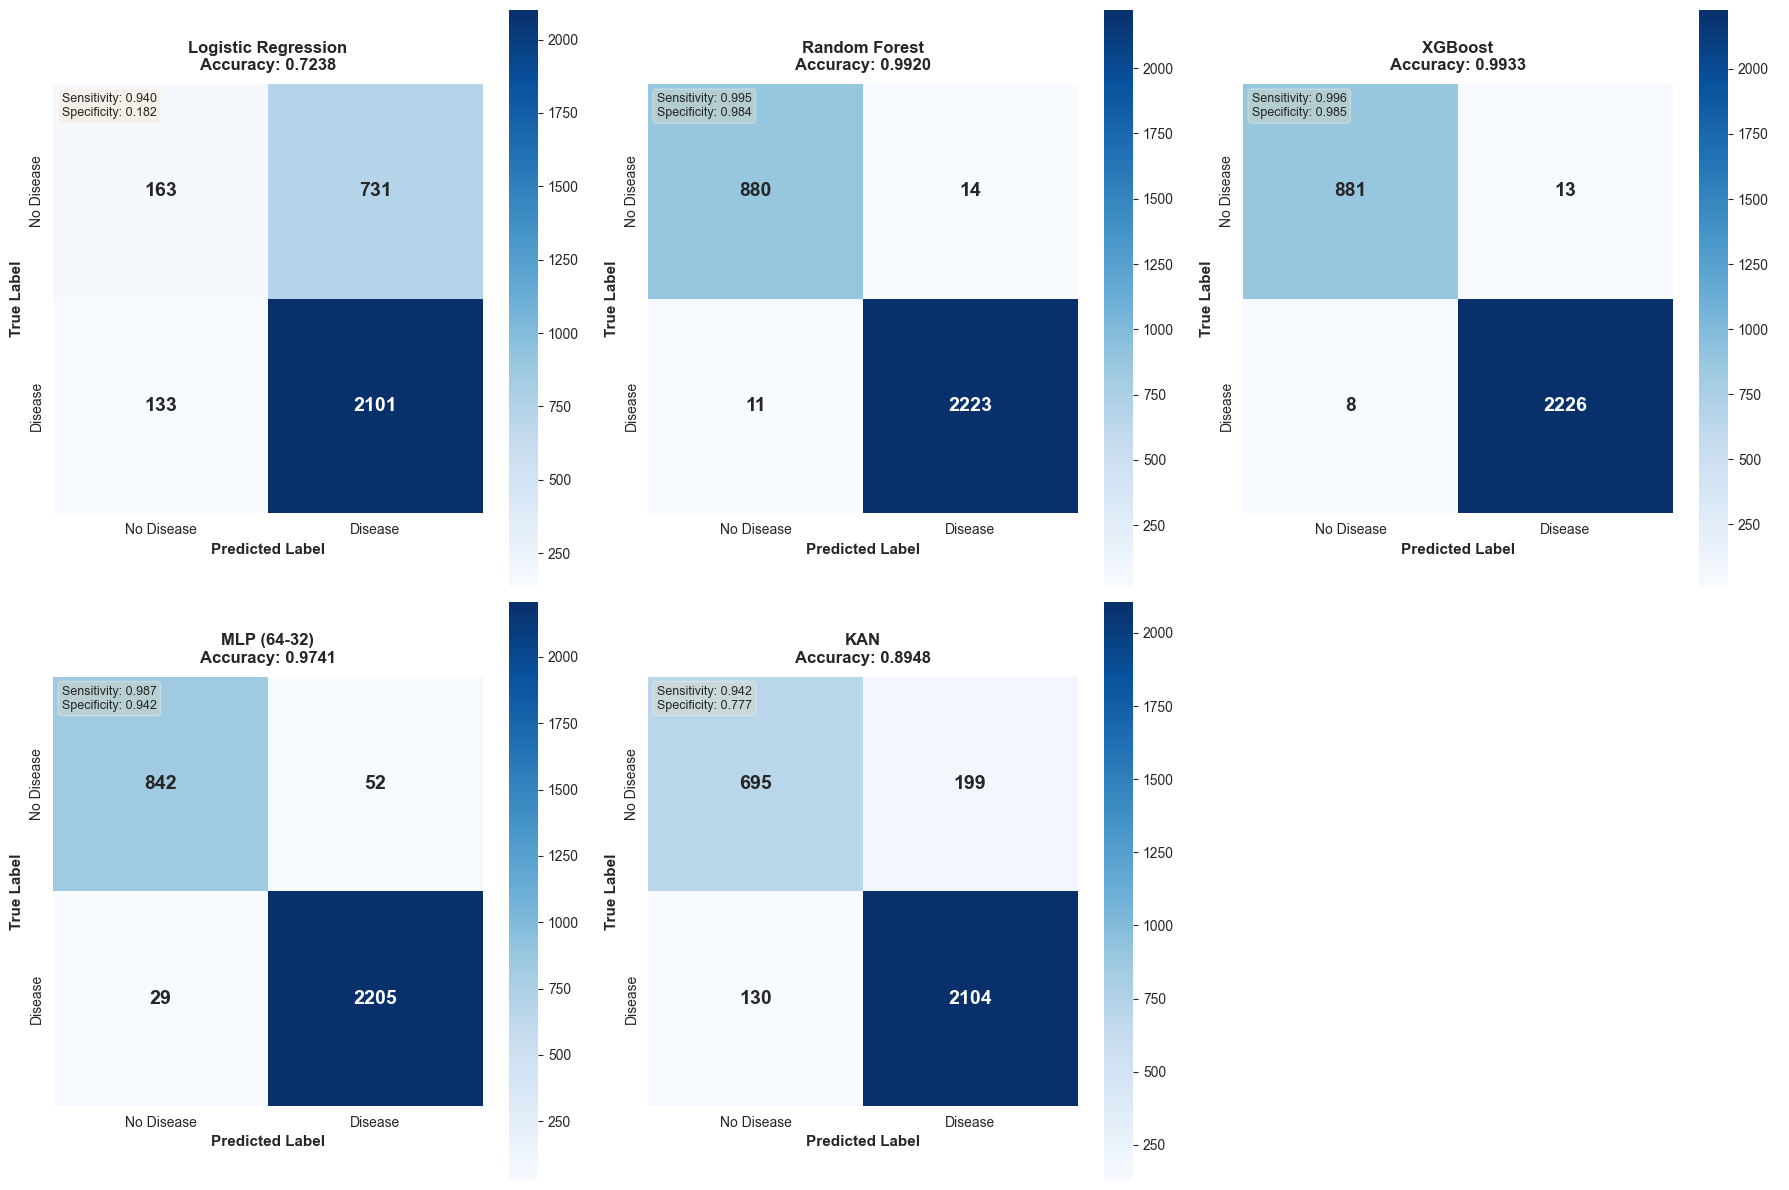


✓ Confusion matrices generated for all 5 models


In [47]:
# Create confusion matrices for all models
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

print("="*80)
print("CONFUSION MATRICES - ALL MODELS")
print("="*80)

# Create figure with subplots for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Get all models including KAN
all_models = []
for result in baseline_results:
    y_pred = result['model'].predict(X_test)
    all_models.append({
        'name': result['name'],
        'y_pred': y_pred,
        'accuracy': result['test_accuracy']
    })

# Add KAN predictions
with torch.no_grad():
    kan_logits = trained_kan(X_test_tensor.to(device))
    kan_probs = torch.sigmoid(kan_logits)
    kan_preds = (kan_probs >= 0.5).float().cpu().numpy().flatten()

all_models.append({
    'name': 'KAN',
    'y_pred': kan_preds,
    'accuracy': kan_results['test_accuracy']
})

# Plot confusion matrix for each model
for idx, model_data in enumerate(all_models):
    cm = confusion_matrix(y_test, model_data['y_pred'])
    
    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                ax=axes[idx], cbar=True, square=True,
                annot_kws={'size': 14, 'weight': 'bold'})
    
    axes[idx].set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{model_data["name"]}\nAccuracy: {model_data["accuracy"]:.4f}', 
                        fontsize=12, fontweight='bold', pad=10)
    
    # Calculate metrics for annotation
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # Add text box with additional metrics
    textstr = f'Sensitivity: {sensitivity:.3f}\nSpecificity: {specificity:.3f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.3)
    axes[idx].text(0.02, 0.98, textstr, transform=axes[idx].transAxes, 
                   fontsize=9, verticalalignment='top', bbox=props)

# Hide the extra subplot
axes[5].axis('off')

plt.tight_layout()
confusion_matrix_fig = plt.gcf()
plt.show()

print("\n✓ Confusion matrices generated for all 5 models")
print("="*80)

### Detailed Evaluation Metrics Table

Comprehensive evaluation metrics for all models across train, validation, and test sets.

In [48]:
# Create comprehensive evaluation metrics table
print("="*120)
print("COMPREHENSIVE EVALUATION METRICS - ALL MODELS")
print("="*120)

# Create detailed metrics dataframe
detailed_metrics = []

for result in baseline_results:
    detailed_metrics.append({
        'Model': result['name'],
        'Train_Acc': result['train_accuracy'],
        'Train_Prec': result['train_precision'],
        'Train_Rec': result['train_recall'],
        'Train_F1': result['train_f1'],
        'Train_AUC': result['train_roc_auc'],
        'Val_Acc': result['val_accuracy'],
        'Val_Prec': result['val_precision'],
        'Val_Rec': result['val_recall'],
        'Val_F1': result['val_f1'],
        'Val_AUC': result['val_roc_auc'],
        'Test_Acc': result['test_accuracy'],
        'Test_Prec': result['test_precision'],
        'Test_Rec': result['test_recall'],
        'Test_F1': result['test_f1'],
        'Test_AUC': result['test_roc_auc']
    })

# Calculate KAN metrics on train and val sets
print("\n[Computing KAN metrics on all splits...]")

# Train set
with torch.no_grad():
    train_logits = trained_kan(X_train_tensor.to(device))
    train_probs = torch.sigmoid(train_logits).cpu().numpy().flatten()
    train_preds = (train_probs >= 0.5).astype(int)

kan_train_acc = accuracy_score(y_train, train_preds)
kan_train_prec = precision_score(y_train, train_preds, zero_division=0)
kan_train_rec = recall_score(y_train, train_preds, zero_division=0)
kan_train_f1 = f1_score(y_train, train_preds, zero_division=0)
kan_train_auc = roc_auc_score(y_train, train_probs)

# Val set
with torch.no_grad():
    val_logits = trained_kan(X_val_tensor.to(device))
    val_probs = torch.sigmoid(val_logits).cpu().numpy().flatten()
    val_preds = (val_probs >= 0.5).astype(int)

kan_val_acc = accuracy_score(y_val, val_preds)
kan_val_prec = precision_score(y_val, val_preds, zero_division=0)
kan_val_rec = recall_score(y_val, val_preds, zero_division=0)
kan_val_f1 = f1_score(y_val, val_preds, zero_division=0)
kan_val_auc = roc_auc_score(y_val, val_probs)

detailed_metrics.append({
    'Model': 'KAN',
    'Train_Acc': kan_train_acc,
    'Train_Prec': kan_train_prec,
    'Train_Rec': kan_train_rec,
    'Train_F1': kan_train_f1,
    'Train_AUC': kan_train_auc,
    'Val_Acc': kan_val_acc,
    'Val_Prec': kan_val_prec,
    'Val_Rec': kan_val_rec,
    'Val_F1': kan_val_f1,
    'Val_AUC': kan_val_auc,
    'Test_Acc': kan_results['test_accuracy'],
    'Test_Prec': kan_results['test_precision'],
    'Test_Rec': kan_results['test_recall'],
    'Test_F1': kan_results['test_f1'],
    'Test_AUC': kan_results['test_roc_auc']
})

detailed_metrics_df = pd.DataFrame(detailed_metrics)

# Sort by Test AUC
detailed_metrics_df = detailed_metrics_df.sort_values('Test_AUC', ascending=False).reset_index(drop=True)

print("   ✓ Metrics computed for all models\n")

# Display training set metrics
print("\n" + "="*120)
print("TRAINING SET METRICS")
print("="*120)
train_cols = ['Model', 'Train_Acc', 'Train_Prec', 'Train_Rec', 'Train_F1', 'Train_AUC']
print(detailed_metrics_df[train_cols].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Display validation set metrics
print("\n" + "="*120)
print("VALIDATION SET METRICS")
print("="*120)
val_cols = ['Model', 'Val_Acc', 'Val_Prec', 'Val_Rec', 'Val_F1', 'Val_AUC']
print(detailed_metrics_df[val_cols].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Display test set metrics
print("\n" + "="*120)
print("TEST SET METRICS (FINAL EVALUATION)")
print("="*120)
test_cols = ['Model', 'Test_Acc', 'Test_Prec', 'Test_Rec', 'Test_F1', 'Test_AUC']
print(detailed_metrics_df[test_cols].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print("\n" + "="*120)

# Save detailed metrics
detailed_metrics_df.to_csv('models/detailed_evaluation_metrics.csv', index=False)
print("\n✓ Saved: models/detailed_evaluation_metrics.csv")
print("="*120)

COMPREHENSIVE EVALUATION METRICS - ALL MODELS

[Computing KAN metrics on all splits...]
   ✓ Metrics computed for all models


TRAINING SET METRICS
              Model  Train_Acc  Train_Prec  Train_Rec  Train_F1  Train_AUC
      Random Forest     0.9941      0.9945     0.9973    0.9959     0.9997
            XGBoost     0.9962      0.9968     0.9980    0.9974     0.9996
        MLP (64-32)     0.9829      0.9856     0.9905    0.9881     0.9963
                KAN     0.8903      0.9076     0.9423    0.9246     0.9559
Logistic Regression     0.7239      0.7415     0.9418    0.8297     0.7615

VALIDATION SET METRICS
              Model  Val_Acc  Val_Prec  Val_Rec  Val_F1  Val_AUC
      Random Forest   0.9866    0.9854   0.9960  0.9907   0.9985
            XGBoost   0.9930    0.9929   0.9973  0.9951   0.9963
        MLP (64-32)   0.9770    0.9792   0.9888  0.9840   0.9892
                KAN   0.8881    0.9067   0.9400  0.9231   0.9511
Logistic Regression   0.7263    0.7435   0.9418  0.83